# Project 1 on Machine Learning: regression analysis, resampling methods and gradient descent

**Data Analysis and Machine Learning FYS-STK3155/FYS4155, University of Oslo, fall 2026**

**Deadline: October 5 (midnight), 2026.** Published August 31, 2026.

This notebook is the Jupyter version of the project text (`Project1.pdf`). The
code cells are *starting points*, not solutions: they set up the data and show
the automatic-differentiation check asked for in part e). Everything else is
yours to write.

## Preamble: note on writing reports, using reference material, AI and other tools

We want you to answer the three different projects by handing in reports
written like a standard scientific/technical report. The links at
<https://github.com/EducationalMaterialUiO/MachineLearningUiO/tree/main/doc/Projects>
contain more information. There you can find examples of previous reports, the
projects themselves, how we grade reports etc. How to write reports will also be
discussed during the various lab sessions. Please do ask us if you are in doubt.
In that folder you will find how we evaluate the projects. You will receive a
feedback with a final score for each project.

When using codes and material from other sources, you should refer to these in
the bibliography of your report, indicating wherefrom you for example got the
code, whether this is from the lecture notes, software like **Scikit-Learn**,
**JAX**, **TensorFlow**, **PyTorch** or other sources. These sources should
always be cited correctly. How to cite some of the libraries is often indicated
from their corresponding GitHub sites or websites; see for example how to cite
Scikit-Learn at <https://scikit-learn.org/dev/about.html>.

We encourage you to use Large Language models (LLMs) like
[ChatGPT](https://openai.com/chatgpt/), [Claude](https://claude.ai) or similar
in writing the report and in developing your code. In the report, you should
after the conclusions, write a declaration on how you have used LLMs following
the instructions at
<https://github.com/EducationalMaterialUiO/MachineLearningUiO/blob/main/LLM_Usage_Declaration_Guidelines.md>.
Failing to do so, <u>leads to an automatic deduction of five (5) points out of
the final score of 100 for the project</u>. Remember that *you* are responsible
for every line of code and every claim in the report: be prepared to explain and
defend all of it. If you use LLMs, please take a look at the guidelines at
<https://github.com/EducationalMaterialUiO/MachineLearningUiO/tree/main/doc/UsingLLMs>
on how to use these tools efficiently.

If you would like to study other data sets, feel free to propose other sets.
What we have proposed here are mere suggestions from our side. If you opt for
another data set, consider using a set which has been studied in the scientific
literature. This makes it easier for you to compare and analyze your results.
Comparing with existing results from the scientific literature is also an
essential element of the scientific discussion. The University of California at
Irvine with its Machine Learning repository at
<https://archive.ics.uci.edu/ml/index.php> is an excellent site to look up for
examples and inspiration. [Kaggle.com](https://www.kaggle.com/) is an equally
interesting site. Feel free to explore these sites and/or ask us for inputs
relevant to your discipline. When selecting other data sets, make sure these
are sets used for regression problems (not classification).

## Regression analysis, resampling methods and gradient descent

The main aim of this project is to study in more detail various regression
methods, including Ordinary Least Squares (OLS) regression, Ridge regression and
Lasso regression, together with the two resampling techniques (the bootstrap and
cross-validation) that let us assess and select models, and the gradient descent
methods that will be our optimizers for the rest of the course. In addition to
the scientific part, in this course we want also to give you an experience in
writing scientific reports.

We will study how to fit polynomials to a specific one-dimensional function
(feel free to replace the suggested function with more complicated ones). We
will use Runge's function (see
<https://en.wikipedia.org/wiki/Runge%27s_phenomenon> for a discussion),

$$
f(x) = \frac{1}{1+25x^2}, \qquad x \in [-1, 1].
$$

The project is organized so that it follows the weekly exercises and lectures of
the first weeks of the course:

- **Parts a) and b):** OLS and Ridge regression with closed-form solutions
  (weeks 34–36; the exercise sets of weeks 35 and 36 can be reused directly).
- **Parts c) and d):** the bias-variance tradeoff studied with the bootstrap,
  and cross-validation (week 36; Chapter 2, Sections 2.9–2.12 of the lecture
  notes).
- **Parts e) and f):** replacing the closed-form solutions by gradient descent,
  with gradients computed both analytically and by automatic differentiation,
  and with momentum and adaptive learning rates (weeks 37–38; Chapter 4).
- **Parts g) and h):** Lasso regression, our first method without a closed-form
  solution, and stochastic gradient descent (Chapter 4 of the lecture notes).
- **Part i):** the final comparison of OLS, Ridge and Lasso using
  cross-validation.

The analytical parts (in particular the derivation of the bias-variance
decomposition in part c) belong in the theory section of your report.
The material for solving the various exercises is covered by Chapters 2–4 of
the lecture notes and the lecture material for weeks 34–38.

## Imports ## 

In [1]:
import numpy as np 
import matplotlib.pyplot as plt 

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.utils import resample

BLUE, RED, YELLOW, GREEN, PINK= "#004488", "#BB5566", "#DDAA33" , "#29C44F" , "#DD338B" 
colors = BLUE, RED, YELLOW, GREEN, PINK

### Setting up the data

A starting point: Runge's function on $[-1,1]$ with additive Gaussian noise,
and a polynomial design matrix. Feel free to change everything.

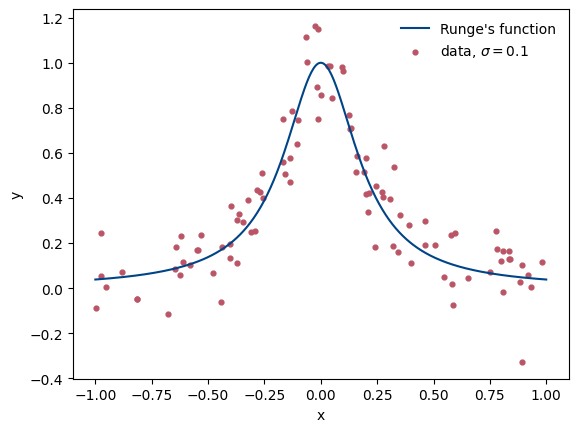

In [2]:

def runge(x):
    return 1.0 / (1.0 + 25.0 * x**2)

def design_matrix(x, degree, intercept=True):
    # polynomial features [1, x, x^2, ..., x^degree] (drop the 1 if intercept=False)
    start = 0 if intercept else 1
    return np.vstack([x**p for p in range(start, degree + 1)]).T

rng = np.random.default_rng(2026)
n = 100
sigma = 0.1                                  # noise level: explore it!
x = np.sort(rng.uniform(-1, 1, n))
y = runge(x) + rng.normal(0, sigma, n)


xx = np.linspace(-1, 1, 400)
plt.plot(xx, runge(xx), color="#004488", label="Runge's function")
plt.scatter(x, y, s=12, color="#BB5566", label=rf"data, $\sigma={sigma}$")
plt.xlabel("x"); plt.ylabel("y"); plt.legend(frameon=False)
plt.show()

### Part a): Ordinary Least Squares (OLS) for the Runge function

We will generate our own data set for the above function $f(x)$ with
$x\in[-1,1]$, using either a uniform distribution or a fixed step size to set up
the array of $x$ values. You should also explore the addition of normally
distributed noise $\varepsilon\sim\mathcal{N}(0,\sigma^2)$ to the function; a
noise level of $\sigma\approx0.1$ is a good starting point, but study how your
conclusions depend on it.

**Write your own code** (using for example the pseudoinverse function `pinv`
from `numpy`, or the SVD directly) and perform a standard **ordinary least
squares regression** analysis using polynomials in $x$ up to order 15 or higher.
Explore the dependence on the number of data points and the polynomial degree.

Evaluate the mean squared error (MSE)

$$
\mathrm{MSE}(\boldsymbol{y},\tilde{\boldsymbol{y}}) = \frac{1}{n}\sum_{i=0}^{n-1}(y_i-\tilde{y}_i)^2,
$$

and the $R^2$ score function. If $\tilde{y}_i$ is the predicted value of the
$i$-th sample and $y_i$ is the corresponding true value, then the score $R^2$ is
defined as

$$
R^2(\boldsymbol{y},\tilde{\boldsymbol{y}}) = 1 - \frac{\sum_{i=0}^{n-1}(y_i-\tilde{y}_i)^2}{\sum_{i=0}^{n-1}(y_i-\bar{y})^2},
\qquad
\bar{y} = \frac{1}{n}\sum_{i=0}^{n-1}y_i .
$$

Plot the resulting scores (MSE and $R^2$) as functions of the polynomial degree
(here up to polynomial degree 15). Plot also the parameters $\boldsymbol{\theta}$
as you increase the order of the polynomial. Comment your results.

Your code has to include a scaling/centering of the data (for example by
subtracting the mean value), and a split of the data in training and test data.
For the splitting you can either write your own code or use for example the
function `train_test_split` provided by **Scikit-Learn** (make sure you have
installed it). **You should present a critical discussion of why and how you
have scaled/ or not scaled the data** (see Section 3.13 of the lecture notes,
the Tuesday session of week 35 and the pertinent notebook for week 35).

It is normal in essentially all Machine Learning studies to split the data in a
training set and a test set (eventually also an additional validation set).
There is no explicit recipe for how much data should be included as training
data and say test data. An accepted rule of thumb is to use approximately $2/3$
to $4/5$ of the data as training data.

You can easily reuse the solutions to your exercises from week 35 (the
analytical derivatives of the cost function, your own OLS code, and the
train/test analysis). See also the lecture slides from weeks 34 and 35 and
Chapter 3 of the lecture notes. On scaling, we recommend reading the following
section from the Scikit-Learn documentation:
<https://scikit-learn.org/stable/auto_examples/preprocessing/plot_all_scaling.html>.
See also Section 3.13 of the lecture notes.

In [3]:
def mse_r2_model(x,y,degree,test_size,random_state):
    n = len(x) # number of datapoints
    X = design_matrix(x, degree, intercept=False) # create design matrix without intercept

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state) # split data into test and training sets, test size as input in function

    # Standardize using training data 
    X_mean = X_train.mean(axis=0) # Finds mean value of training data in design matrix
    X_std = X_train.std(axis=0) # Finds standard deviation of train data in design matrix
    X_std[X_std == 0] = 1  # Safeguard to avoid division by zero for constant features

    X_train = (X_train - X_mean) / X_std # Standardizing training design matrix
    X_test = (X_test - X_mean) / X_std # Standardizing test design matrix

    # Centering y with the training data 
    y_mean = y_train.mean() # finding mean of y training dataset
    y_train = y_train - y_mean # centering training y data
    y_test = y_test - y_mean  # centering test y data


    # OLS using numpy pinv 
    theta = np.linalg.pinv(X_train) @ y_train # finding model theta coefficients using closed form OLS 

    ypred_train = X_train @ theta # finding predicted training y-values
    ypred_test = X_test @ theta  # finding predicted test y-values

    mse_train = mean_squared_error(y_train, ypred_train) # finding mean squared error of training y-values
    mse_test = mean_squared_error(y_test, ypred_test) # finding mean squared error of test y-values

    r2_train = r2_score(y_train, ypred_train) # finding r2 score of training y-values
    r2_test = r2_score(y_test, ypred_test) # finding r2 score of test y-values


    return mse_train, mse_test, r2_train, r2_test, theta # returning mean squared error and r2 score values, and theta

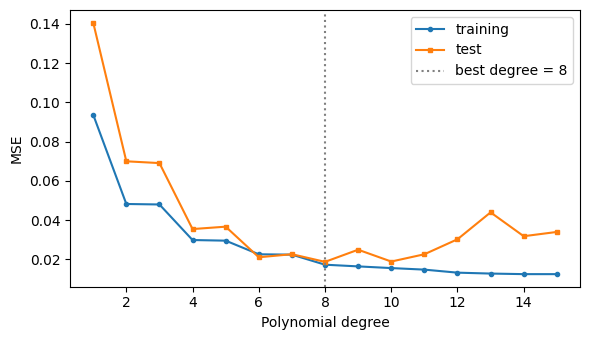

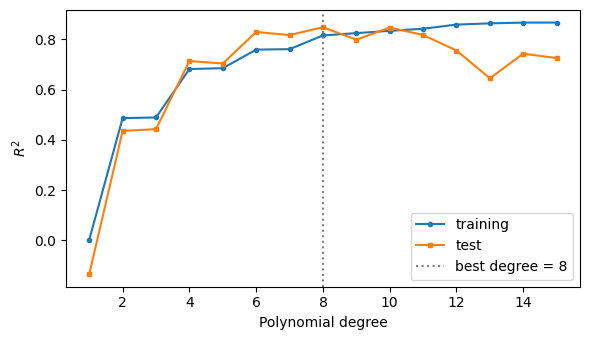

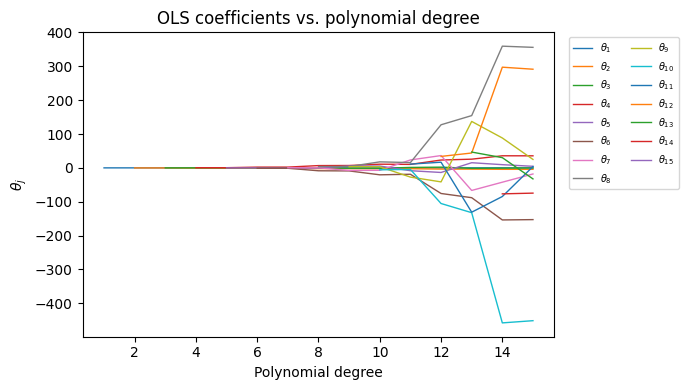

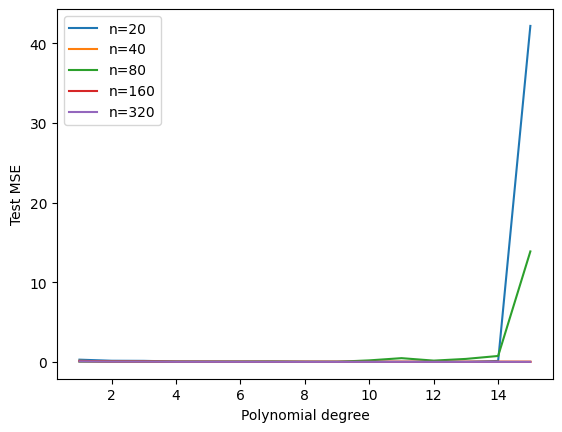

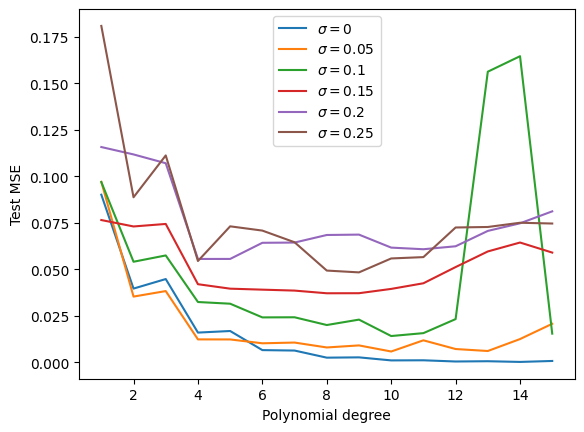

In [4]:
# Analysis degree 0-15
degrees = np.arange(1,16) # degrees 1-15

mse_train_array = np.zeros(len(degrees)) # creating array to fill with mse values of different polynomial degrees for training data
mse_test_array = np.zeros(len(degrees)) # same for test

r2_train_array = np.zeros(len(degrees)) # creating array to fill with r^2 score values of different polynomial degrees for training data
r2_test_array = np.zeros(len(degrees)) # same for test

theta_array = [] # to fill with fitted model theta coefficient of training data

for i, degree in enumerate(degrees): # running through each degree (counting index at same time)

    (mse_train_array[i], 
    mse_test_array[i], 
    r2_train_array[i], 
    r2_test_array[i], 
    theta) = mse_r2_model(x, y, degree, 0.2, 2026)  # using the function on runge function, test size 20% of data, and seed 2026

    theta_array.append(theta) # adding theta coefficinent for this degree



best_degree_idx = int(np.argmin(mse_test_array)) # finding the optimal polynomial degree based on which one gave the minimum mse value


# Plotting, used LLM Claude to fix the figsize, colorschemes and labels 

# MSE for OLS
plt.figure(figsize=(6, 3.5))
plt.plot(degrees, mse_train_array, "o-", ms=3, label="training")
plt.plot(degrees, mse_test_array, "s-", ms=3, label="test")
plt.axvline(degrees[best_degree_idx], color="gray", ls=":",
            label=f"best degree = {degrees[best_degree_idx]}")
plt.xlabel("Polynomial degree")
plt.ylabel("MSE")
plt.legend()
plt.tight_layout()
plt.savefig('figures/a_mse_poly.png')
plt.show()

# R^2 score for OLS
plt.figure(figsize=(6, 3.5))
plt.plot(degrees, r2_train_array, "o-", ms=3, label="training")
plt.plot(degrees, r2_test_array, "s-", ms=3, label="test")
plt.axvline(degrees[best_degree_idx], color="gray", ls=":",
            label=f"best degree = {degrees[best_degree_idx]}")
plt.xlabel("Polynomial degree")
plt.ylabel(r"$R^2$")
plt.legend()
plt.tight_layout()
plt.savefig('figures/a_r2_poly.png')
plt.show()

# Plotting parameters theta over polynomial degree - LLM Claude made this loop
plt.figure(figsize=(7, 4))
max_degree = degrees[-1]

for j in range(max_degree):      # j = coefficient index; theta[j] multiplies x^(j+1), since there is no intercept column
    xs, ys = [], []
    for d, th in zip(degrees, theta_array):
        if len(th) > j:          # only include degrees whose model has a coefficient number j
            xs.append(d)         # polynomial degree of this model
            ys.append(th[j])     # value of coefficient j in this model
    plt.plot(xs, ys, lw=1, label=rf"$\theta_{{{j+1}}}$")   # labeled by the power of x it multiplies

plt.xlabel("Polynomial degree")
plt.ylabel(r"$\theta_j$")
plt.title("OLS coefficients vs. polynomial degree")
plt.legend(ncol=2, fontsize=7, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig('figures/a_theta_poly.png')
plt.show()

# Plotting dependance on number of datapoints
data_points = [20, 40, 80, 160, 320]

plt.figure()

for n_ in data_points: # running through each number of datapoints
    # using the runge dataset and defining it for specific number of datapoints
    x_n = np.sort(rng.uniform(-1, 1, n_)) 
    y_n = runge(x_n) + rng.normal(0, sigma, n_)

    mse_test_n = np.zeros(len(degrees)) # creating array to fill with mean squared error test data values for each degree

    for i, degree in enumerate(degrees): # running though all degrees 

        (mse_train_n,
         mse_test_n[i],
         r2_train_n,
         r2_test_n,
         theta_n) = mse_r2_model(
             x_n, y_n, degree, 0.2, 2026) # finding the mse value for this number of datapoints for every degree

    plt.plot(degrees, mse_test_n, label=f'n={n_}') #plotting the mse over degrees for this number of datapoints

plt.xlabel('Polynomial degree')
plt.ylabel('Test MSE')
plt.legend()
plt.savefig('figures/a_n_poly.png')
plt.show()

# Plotting dependance on noise 

sigma_values = [0, 0.05, 0.1, 0.15, 0.2, 0.25]

plt.figure() 

for s in sigma_values: # running though every noise value
    # defining the dataset based on this noise value
    x_s = np.sort(rng.uniform(-1, 1, n)) 
    y_s = runge(x_s) + rng.normal(0, s, n)

    mse_test_s = np.zeros(len(degrees))

    for i, degree in enumerate(degrees):

        (mse_train_s, 
         mse_test_s[i],
         r2_train_s,
         r2_test_s,
         theta_s) = mse_r2_model(x_s, y_s, degree, 0.2, 2026) # finding the test mse for every polynomial degree for this noise value

    plt.plot(degrees, mse_test_s, label=rf'$\sigma={s}$') # plotting the test mse for every polynomial degree based on this noise value

plt.xlabel('Polynomial degree')
plt.ylabel('Test MSE')
plt.legend()
plt.savefig('figures/a_sigma_poly.png')
plt.show()

### Part b): Adding Ridge regression for the Runge function

Write your own code for the Ridge method, as done in the previous part. The
lecture notes from weeks 35 and 36 contain more information, as well as your
exercises from weeks 35 and 36. Feel free to reuse this material.

Perform the same analysis as you did in the previous part but now for different
values of the penalty parameter $\lambda$. Compare and analyze your results with
those obtained in part a) with the OLS method. Study the dependence on
$\lambda$, and connect what you see to the shrinkage of the singular-value modes
discussed in the lectures (Section 3.8 of the lecture notes).

In [5]:
def ridge_svd(X, y, lmbda):
    """Ridge through the SVD: sum_i sigma_i/(sigma_i^2 + lambda) (u_i . y) v_i.

    Solves min ||y - X theta||^2 + lambda ||theta||^2  (no 1/n factor).
    """
    U, s, Vt = np.linalg.svd(X, full_matrices=False) # Finding singular value decomposition, using numpy module
    return Vt.T @ (s / (s**2 + lmbda) * (U.T @ y)) # returning estimated Ridge coefficients/theta values

def mse_r2_model_ridge(x, y, degree, test_size, random_state, lambdas):
    X = design_matrix(x, degree, intercept=False) # setting up the design matrix without intercept

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state) # splitting data

    # Standardize using training data, as in a
    X_mean = X_train.mean(axis=0)
    X_std = X_train.std(axis=0)
    X_std[X_std == 0] = 1 
    X_train = (X_train - X_mean) / X_std
    X_test = (X_test - X_mean) / X_std

    # Center y using the training data, as in a
    y_mean = y_train.mean()
    y_train = y_train - y_mean
    y_test = y_test - y_mean

    mse_tr_r, mse_te_r, r2_tr_r, r2_te_r, dfs, thetas = [], [], [], [], [], [] # empty list to fill with MSE, R^2 score, degree of freedom and theta values
    s = np.linalg.svd(X_train, compute_uv=False)  # finding the singular values of the training design matrix

    for lam in lambdas: # for each lambda value
        theta = ridge_svd(X_train, y_train, lam)  # theta for this lambda, fit on centered training data
        ypred_train = X_train @ theta # finding predicted training y-values 
        ypred_test = X_test @ theta # finding predicted test y-values

        mse_tr_r.append(mean_squared_error(y_train, ypred_train)) # valculating training MSE for this lambda and adding to list
        mse_te_r.append(mean_squared_error(y_test, ypred_test)) # same for test MSE
        r2_tr_r.append(r2_score(y_train, ypred_train)) # same for R^2 score
        r2_te_r.append(r2_score(y_test, ypred_test))
        dfs.append(np.sum(s**2 / (s**2 + lam)))    # calculating effective degrees of freedom
        thetas.append(theta)


    return np.array(mse_tr_r), np.array(mse_te_r), np.array(r2_tr_r), np.array(r2_te_r), np.array(dfs), thetas


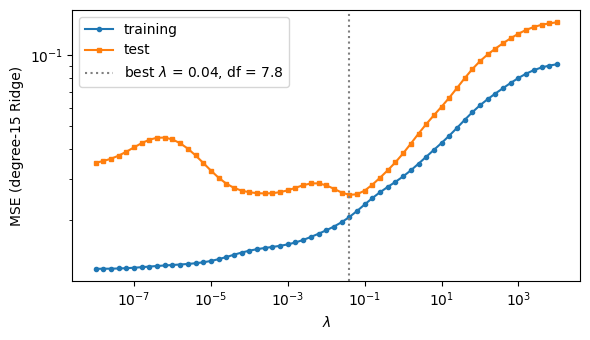

best Ridge test MSE 0.02562 at lambda 0.0398 (effective dof 7.78)


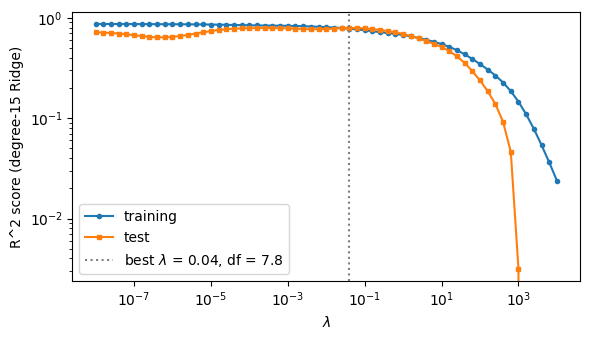

In [6]:
lambdas = np.logspace(-8, 4, 61) # 61 different lambda values to investigate
mse_tr_r, mse_te_r, r2_tr_r, r2_te_r, dfs, thetas = mse_r2_model_ridge(x, y, 15, 0.2, 2026, lambdas) # for runge function data, degree 15 polynomial, 20% test size, 2026 seed and all lambda values

best = int(np.argmin(mse_te_r))  # index of the lambda with lowest test MSE

# Used LLM to make plots look nice, plotting MSE over lambda values
plt.figure(figsize=(6, 3.5))
plt.plot(lambdas, mse_tr_r, "o-", ms=3, label="training")
plt.plot(lambdas, mse_te_r, "s-", ms=3, label="test")
plt.axvline(lambdas[best], color="gray", ls=":",
            label=rf"best $\lambda$ = {lambdas[best]:.2g}, df = {dfs[best]:.1f}") # adding vertical line for best lambda value (lowest mse) and corresponding degree of freedom
plt.xscale("log"); plt.yscale("log")
plt.xlabel(r"$\lambda$"); plt.ylabel(f"MSE (degree-{degree} Ridge)"); plt.legend()
plt.savefig('figures/b_mse_poly.png')
plt.tight_layout(); plt.show()

print(f"best Ridge test MSE {mse_te_r[best]:.5f} at lambda {lambdas[best]:.3g} "
        f"(effective dof {dfs[best]:.2f})")

# Plotting R^2 score over lambda values 
plt.figure(figsize=(6, 3.5))
plt.plot(lambdas, r2_tr_r, "o-", ms=3, label="training")
plt.plot(lambdas, r2_te_r, "s-", ms=3, label="test")
plt.axvline(lambdas[best], color="gray", ls=":",
            label=rf"best $\lambda$ = {lambdas[best]:.2g}, df = {dfs[best]:.1f}")
plt.xscale("log"); plt.yscale("log")
plt.xlabel(r"$\lambda$"); plt.ylabel(f"R^2 score (degree-{degree} Ridge)"); plt.legend()
plt.savefig('figures/b_r2_poly.png')
plt.tight_layout(); plt.show()

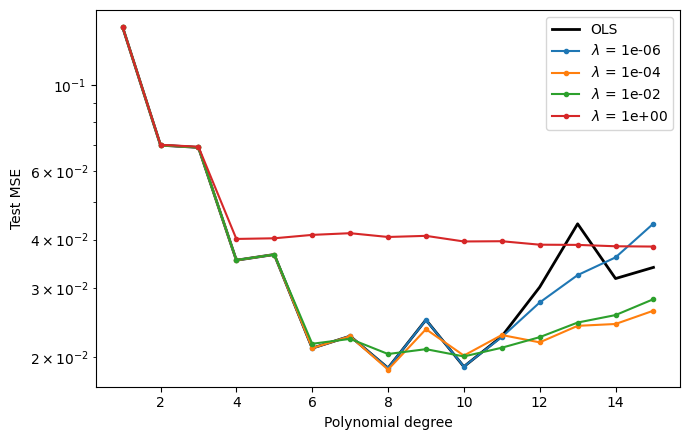

best: degree 8, lambda 1e-04, test MSE 0.01854


In [7]:
# same analysis as part a, for several lambdas
lambdas_b = [1e-6, 1e-4, 1e-2, 1e0] 

mse_train_ridge = np.zeros((len(degrees), len(lambdas_b))) # MSE for every degree, and for every lambda value
mse_test_ridge = np.zeros((len(degrees), len(lambdas_b)))

r2_train_ridge = np.zeros((len(degrees), len(lambdas_b)))
r2_test_ridge = np.zeros((len(degrees), len(lambdas_b)))

for i_deg, deg in enumerate(degrees): # for every degree 1-15 (counting index to fill empty arrays)

    (mse_train_ridge[i_deg],
    mse_test_ridge[i_deg],
    r2_train_ridge[i_deg],
    r2_test_ridge[i_deg],
    _, _) = mse_r2_model_ridge(x, y, deg, 0.2, 2026, lambdas_b) # finding MSE (only use this) for each lambda value using ridge solving function
    # same split, standardization and centering as part a

plt.figure(figsize=(7, 4.5))
plt.plot(degrees, mse_test_array, "k-", lw=2, label="OLS") # comparing to solution in a
for j, lam in enumerate(lambdas_b):
    plt.plot(degrees, mse_test_ridge[:, j], "o-", ms=3, label=rf"$\lambda$ = {lam:.0e}") # plotting test MSE over degrees for every lambda value
plt.xlabel("Polynomial degree")
plt.ylabel("Test MSE")
plt.yscale("log")
plt.legend()
plt.tight_layout()
plt.savefig('figures/b_OLSRidge_poly.png')
plt.show()

i_best, j_best = np.unravel_index(np.argmin(mse_test_ridge), mse_test_ridge.shape) # finding best degree and corresponding lambda value
print(f"best: degree {degrees[i_best]}, lambda {lambdas_b[j_best]:.0e}, test MSE {mse_test_ridge[i_best, j_best]:.5f}")

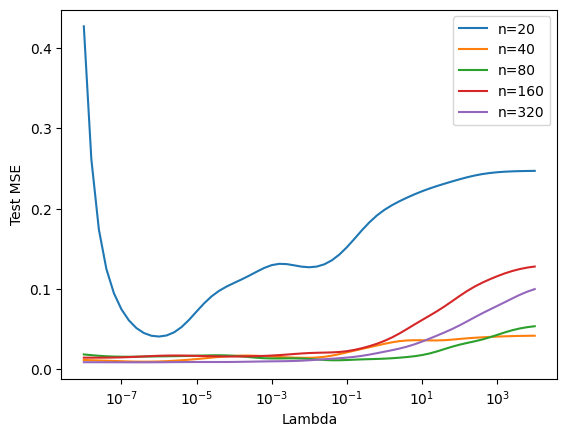

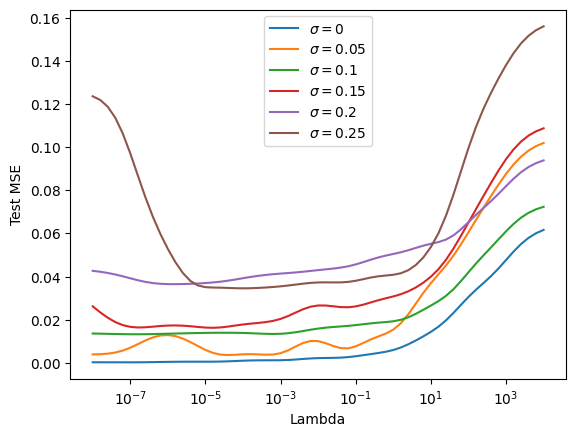

In [8]:
# Dependence on number of datapoints
data_points = [20, 40, 80, 160, 320]

plt.figure()
for n_ in data_points: # for every n value
    x_n = np.sort(rng.uniform(-1, 1, n_)) # defining x based on this number of data points n
    y_n = runge(x_n) + rng.normal(0, sigma, n_) # same for y

    _, mse_test_n_r, _, _, _, _ = mse_r2_model_ridge(x_n, y_n, 15, 0.2, 2026, lambdas) # finding test MSE with function using ridge and using newly defined x,y as input

    plt.plot(lambdas, mse_test_n_r, label=f'n={n_}') # plotting test MSE for this n over lambda values

plt.xscale('log')
plt.xlabel('Lambda')
plt.ylabel('Test MSE')
plt.legend()
plt.savefig('figures/b_n_poly.png')
plt.show()


# Dependence on noise, same method as above
sigma_values = [0, 0.05, 0.1, 0.15, 0.2, 0.25]

plt.figure()
for s in sigma_values:
    x_s = np.sort(rng.uniform(-1, 1, n))
    y_s = runge(x_s) + rng.normal(0, s, n)

    _, mse_test_s_r, _, _, _, _ = mse_r2_model_ridge(x_s, y_s, 15, 0.2, 2026, lambdas)

    plt.plot(lambdas, mse_test_s_r, label=rf'$\sigma={s}$')

plt.xscale('log')
plt.xlabel('Lambda')
plt.ylabel('Test MSE')
plt.legend()
plt.savefig('figures/b_sigma_poly.png')
plt.show()

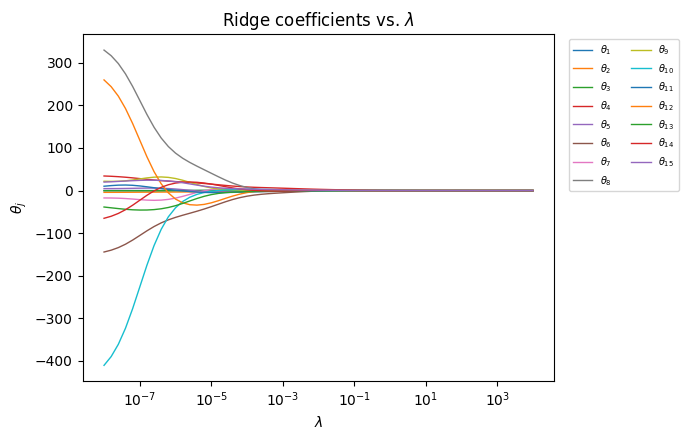

In [9]:
# LLM helped make this plot look nice and create the labeling 

thetas_arr = np.array(thetas)  # shape (n_lambdas, n_features)
plt.figure(figsize=(7, 4.5))
for j in range(thetas_arr.shape[1]):
    plt.plot(lambdas, thetas_arr[:, j], lw=1, label=rf"$\theta_{{{j+1}}}$")  # labeled by the power of x it multiplies
plt.xscale('log')
plt.xlabel(r'$\lambda$'); plt.ylabel(r'$\theta_j$')
plt.title('Ridge coefficients vs. $\\lambda$')
plt.legend(ncol=2, fontsize=7, bbox_to_anchor=(1.02, 1), loc="upper left")  # legend outside the plot
plt.tight_layout()
plt.savefig('figures/b_theta_poly.png')
plt.show()

### Part c): The bias-variance tradeoff and the bootstrap

Our aim here is to study the bias-variance tradeoff by implementing the
**bootstrap** resampling technique. **We will only use the simpler ordinary
least squares here.**

Before you perform an analysis of the bias-variance tradeoff on your test data,
make first a figure similar to Fig. 2.11 of Hastie, Tibshirani and Friedman.
Figure 2.11 of this reference displays only the test and training MSEs. The
test MSE can be used to indicate possible regions of low/high bias and variance.
You will most likely not get an equally smooth curve! You will also need to
increase the polynomial order and play around with the number of data points as
well (see the exercise sets from week 35 and week 36).

With this result we move on to the bias-variance tradeoff analysis. Consider a
data set $\mathcal{L}$ consisting of the data
$\boldsymbol{X}_\mathcal{L}=\{(y_j,\boldsymbol{x}_j),\,j=0,\dots,n-1\}$, and
assume that the true data are generated from a noisy model

$$
\boldsymbol{y} = f(\boldsymbol{x}) + \boldsymbol{\varepsilon},
$$

where $\boldsymbol{\varepsilon}$ is normally distributed with mean zero and
variance $\sigma^2$. In our derivation of the ordinary least squares method we
defined an approximation to the function $f$ in terms of the parameters
$\boldsymbol{\theta}$ and the design matrix $\boldsymbol{X}$ which embody our
model, that is $\tilde{\boldsymbol{y}}=\boldsymbol{X}\boldsymbol{\theta}$. The
parameters $\boldsymbol{\theta}$ are in turn found by optimizing the mean squared
error via the cost function

$$
C(\boldsymbol{X},\boldsymbol{\theta}) = \frac{1}{n}\sum_{i=0}^{n-1}(y_i-\tilde{y}_i)^2
 = \mathbb{E}\left[(\boldsymbol{y}-\tilde{\boldsymbol{y}})^2\right].
$$

Here the expected value $\mathbb{E}$ is the sample value.

Show that you can rewrite this in terms of a term which contains the variance of
the model itself (the so-called variance term), a term which measures the
deviation from the true data and the mean value of the model (the bias term) and
finally the variance of the noise. That is, show that

$$
\mathbb{E}\left[(\boldsymbol{y}-\tilde{\boldsymbol{y}})^2\right]
 = \mathrm{Bias}^2[\tilde{y}] + \mathrm{var}[\tilde{y}] + \sigma^2,
$$

with

$$
\mathrm{Bias}^2[\tilde{y}] = \mathbb{E}\left[\left(\boldsymbol{f}-\mathbb{E}[\tilde{\boldsymbol{y}}]\right)^2\right],
\qquad
\mathrm{var}[\tilde{y}] = \mathbb{E}\left[\left(\tilde{\boldsymbol{y}}-\mathbb{E}[\tilde{\boldsymbol{y}}]\right)^2\right]
 = \frac{1}{n}\sum_i\left(\tilde{y}_i-\mathbb{E}[\tilde{\boldsymbol{y}}]\right)^2 .
$$

**Important note:** since the function $f(x)$ is unknown, in order to be able to
evaluate the bias we replace $f(\boldsymbol{x})$ in the expression for the bias
with $\boldsymbol{y}$; discuss what this does to the measured bias term (it
absorbs the noise variance $\sigma^2$). Explain what the three terms mean and
discuss their interpretations, and state clearly over which randomness the
expectation values are taken.

The answer to this exercise should be included in the theory part of the
report. This derivation is also part of the weekly exercises of week 36, and it
is Eq. (2.52) of Chapter 2 of the lecture notes.

Perform then a bias-variance analysis of the Runge function by studying the MSE
value as function of the complexity of your model, using the **bootstrap**
resampling method to estimate the expectation values over training sets.
Discuss the bias and variance tradeoff as function of your model complexity (the
degree of the polynomial) and the number of data points. You can follow the
code examples in Sections 2.10 and 2.11 of the lecture notes and the Tuesday
notebook of week 36 (`week36tuesday.ipynb`).

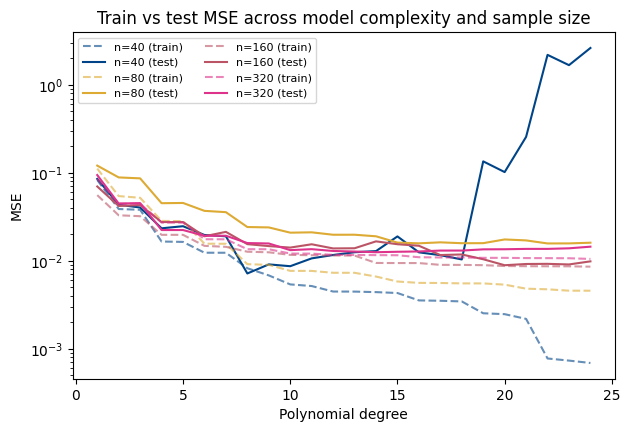

In [10]:
data_points = [40, 80, 160, 320] # defining different number of datapoints
plt.figure(figsize=(7, 4.5))
colors = BLUE, YELLOW, RED , PINK
pol = np.arange(1, 25) # range of polynomial degrees 

for n_, color in zip(data_points, colors): # going through every datapoint number and graph colors to be used in the plot
    x_n = np.sort(rng.uniform(-1, 1, n_)) # using the runge dataset with specific number of datapoints
    y_n = runge(x_n) + rng.normal(0, sigma, n_) # finding corresponding true y-values

    mse_train_n = np.zeros(len(pol)) # to fill with training mse values for each polynomial degree
    mse_test_n = np.zeros(len(pol)) # test mse

    for idx, degree in enumerate(pol): # for every polynomial degree (count index at same time)
        # find mse, r^2 score and theta values using OLS model prediction for each degree and specific number of datapoints
        (mse_train_n[idx], mse_test_n[idx], r2_train_n, r2_test_n, theta_n) = mse_r2_model(x_n, y_n, degree, 0.2, 2026) 

    plt.plot(pol, mse_train_n, '--', color=color, alpha=0.6, label=f'n={n_} (train)') # plotting training mse over polynomial degree
    plt.plot(pol, mse_test_n, '-', color=color, label=f'n={n_} (test)') # test mse

plt.xlabel('Polynomial degree')
plt.ylabel('MSE')
plt.yscale('log')   # values span many orders of magnitude once train MSE starts collapsing
plt.legend(fontsize=8, ncol=2)
plt.title('Train vs test MSE across model complexity and sample size')
plt.savefig('figures/c_mse_poly.png')
plt.show()

degree  1: error 0.1441 ± 0.0296
degree  2: error 0.0725 ± 0.0192
degree  3: error 0.0727 ± 0.0185
degree  4: error 0.0381 ± 0.0113
degree  5: error 0.0408 ± 0.0109
degree  6: error 0.0349 ± 0.0083
degree  7: error 0.0489 ± 0.0129
degree  8: error 0.0334 ± 0.0065
degree  9: error 0.0592 ± 0.0197
degree 10: error 0.0795 ± 0.0335
degree 11: error 0.2760 ± 0.1392
degree 12: error 1.2657 ± 0.7762
degree 13: error 8.4327 ± 6.0556
degree 14: error 9.4991 ± 7.7996
degree 15: error 14.2347 ± 10.7851
degrees that are within one standard error of the minimum: [4 6 8]


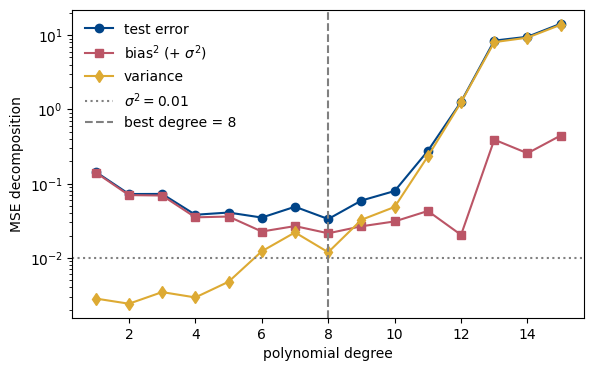

degree  1: error 0.1441  bias^2 0.1412  var 0.0028  sum 0.1441
degree  4: error 0.0381  bias^2 0.0352  var 0.0029  sum 0.0381
degree  6: error 0.0349  bias^2 0.0227  var 0.0123  sum 0.0349
degree  8: error 0.0334  bias^2 0.0214  var 0.0119  sum 0.0334
degree 11: error 0.2760  bias^2 0.0428  var 0.2332  sum 0.2760
degree 15: error 14.2347  bias^2 0.4448  var 13.7900  sum 14.2347


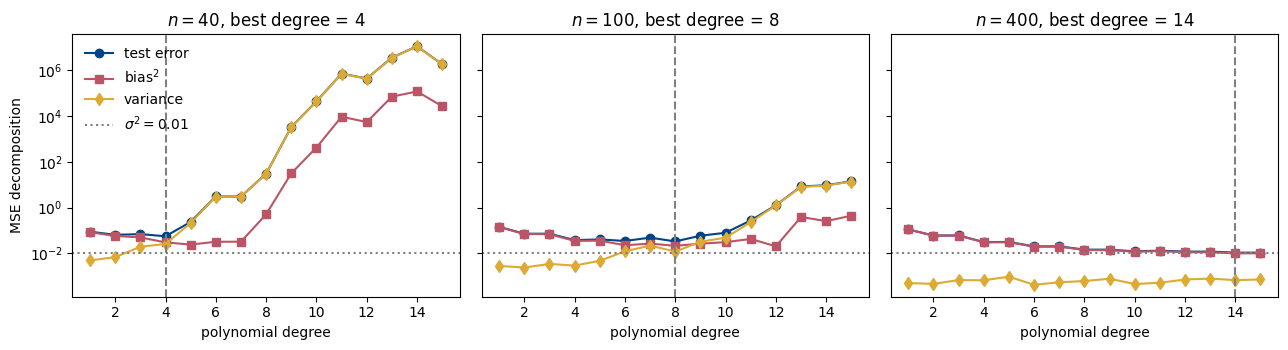

In [11]:

# Your code for part c) here
n_bootstraps, maxdegree = 100, 16 # number of bootstrap resamples and maximal degree investigated
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2026) # splitting data with 20% being test data

x_train = x_train.reshape(-1, 1) # reshaping training data in order to use bootstrap resample function
x_test = x_test.reshape(-1, 1)   # same for testing data

error = np.zeros(len(degrees)) # to fill with error values over all resamples
bias = np.zeros(len(degrees)) # to fill with bias values over all resamples
variance = np.zeros(len(degrees)) # to fill with variance values over all resamples

error_se = np.zeros(len(degrees))

for idx, degree in enumerate(degrees): # endret 
    model = make_pipeline(PolynomialFeatures(degree=degree, include_bias=False), StandardScaler(),
                          LinearRegression()) # sets space to create standardized design matrix without intercept, using OLS method to solve it when fitted
    y_pred = np.empty((y_test.shape[0], n_bootstraps)) # creating array for predicted y of all resampled training data

    for j in range(n_bootstraps): # going through each number of bootstrap resampling
        x_, y_ = resample(x_train, y_train, random_state=j) # finding the bootstrap resampled dataset
        y_pred[:, j] = model.fit(x_, y_).predict(x_test).ravel() # finding predicted y values for specific resample data, predicting with OLS method

    err_points = np.mean((y_test[:, np.newaxis] - y_pred)**2, axis=1)   # error at each test point, averaged over resamples
    error_se[idx] = np.std(err_points, ddof=1) / np.sqrt(len(y_test))   # standard error over the test points

    error[idx] = np.mean((y_test[:, np.newaxis] - y_pred)**2) # finding mean error over all resampled datasets 
    bias[idx] = np.mean((y_test - np.mean(y_pred, axis=1))**2) # finding mean bias over all resampled datasets
    variance[idx] = np.mean(np.var(y_pred, axis=1)) # finding mean variance over all resampled datasets

for d, e, s in zip(degrees, error, error_se):
    print(f"degree {d:2d}: error {e:.4f} ± {s:.4f}")
i_min = np.argmin(error)
print(f'degrees that are within one standard error of the minimum: {degrees[error <= error[i_min] + error_se[i_min]]}')

fig, ax = plt.subplots(figsize=(6.6, 4.0))
ax.plot(degrees, error, "o-", color=BLUE, label="test error") # plotting error over polynomial degree
ax.plot(degrees, bias, "s-", color=RED, label=r"bias$^2$ (+ $\sigma^2$)") # plotting bias over polynomial degree
ax.plot(degrees, variance, "d-", color=YELLOW, label="variance") # plotting variance over polynomial degree
ax.axhline(sigma**2, color="gray", ls=":", label=r"$\sigma^2 = 0.01$") # add a horizontal dotted line at sigma^2 = 0.01, minimum bias value
best = degrees[np.argmin(error)]
ax.axvline(best, color="gray", ls="--", label=f"best degree = {best}")
ax.set_yscale("log")
ax.set_xlabel("polynomial degree")
ax.set_ylabel("MSE decomposition")
ax.legend(frameon=False)
plt.savefig('figures/c_mse_lambda.png')
plt.show()

for i in (0, 3, 5, 7, 10, 14): # going through a few chosen polynomial degrees
    d = degrees[i]
    print(f"degree {d:2d}: error {error[i]:.4f}  bias^2 {bias[i]:.4f}  "
          f"var {variance[i]:.4f}  sum {bias[i] + variance[i]:.4f}") # printing the error, bias, variance and bias variance sum


def bias_variance_sweep(n=40, noise=0.1, maxdegree=16, n_bootstraps=100,
                        make_model=None, seed=2026):
    """Bootstrap estimate of error/bias^2/variance vs polynomial degree."""
    if make_model is None: # if no other model has been chosen, the following is used
        make_model = lambda deg: make_pipeline(
            PolynomialFeatures(degree=deg, include_bias=False), StandardScaler(), LinearRegression())
    np.random.seed(seed) # default model: polynomial features (no intercept column) -> standardization -> OLS (LinearRegression)
    rng = np.random.default_rng(seed)
    x = np.sort(rng.uniform(-1, 1, n)) # n x-values
    y = runge(x) + rng.normal(0, noise, n) # runge function as our observed data with added noise, n datapoints
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,
                                                        random_state=seed) # splitting data using the same seed as in a and b for consistency
    error, bias, variance = (np.zeros(len(degrees)) for _ in range(3)) # making three arrays for error, bias and variance to fill with corresponding mean values over all resamples
    x_train = x_train.reshape(-1, 1) 
    x_test = x_test.reshape(-1, 1)
    for idx, degree in enumerate(degrees): # looping over all degrees
        model = make_model(degree) # new unfitted pipeline (polynomial features -> scaling -> OLS) for this degree
        y_pred = np.empty((y_test.shape[0], n_bootstraps)) # setting up array to fill with predicted y values of all resamples
        for i in range(n_bootstraps): # going through each number i of bootstrap resampling
            x_, y_ = resample(x_train, y_train, random_state=i) # finding the new resample
            y_pred[:, i] = model.fit(x_, y_).predict(x_test).ravel() # finding the predicted y values for this resample
        error[idx] = np.mean((y_test[:, np.newaxis] - y_pred)**2) # finding mean error over all resampled datasets 
        bias[idx] = np.mean((y_test - np.mean(y_pred, axis=1))**2) # finding mean bias over all resampled datasets 
        variance[idx] = np.mean(np.var(y_pred, axis=1, keepdims=True)) # finding mean variance over all resampled datasets 
    return error, bias, variance

#cope and renabme variable to ensure comparison in task d is correct 
error_boot = error.copy()
degrees_boot = degrees.copy ()

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True) # plotting 3 subplots
for ax, n_ in zip(axes, (40, 100, 400)): # for each plot with n datapoints
    err, b2, var = bias_variance_sweep(n=n_) # using the function to find error, bias^2 and variance of each model using bootstrap for every n datapoints
    ax.plot(degrees, err, "o-", color=BLUE, label="test error") # plotting error
    ax.plot(degrees, b2, "s-", color=RED, label=r"bias$^2$") # plotting bias^2
    ax.plot(degrees, var, "d-", color=YELLOW, label="variance") # plotting variance
    best = degrees[np.argmin(err)]
    ax.axvline(best, color="gray", ls="--")
    ax.axhline(sigma**2, color="gray", ls=":", label=r"$\sigma^2 = 0.01$")
    ax.set_yscale("log")
    ax.set_title(f"$n = {n_}$, best degree = {best}")
    ax.set_xlabel("polynomial degree")
axes[0].set_ylabel("MSE decomposition")
axes[0].legend(frameon=False)
plt.tight_layout()
plt.savefig('figures/c_n_lambda.png')
plt.show()

### Part d): Cross-validation as a resampling technique

The aim here is to use another widely popular resampling technique, the
so-called cross-validation method (Section 2.12 of the lecture notes and the
Tuesday session of week 36). For Ridge and Lasso, see also Section 3.14 of the
lecture notes.

Use the $k$-fold cross-validation functionality of **Scikit-Learn** (`KFold`
together with `cross_val_score`, or `cross_validate`) and evaluate again the
MSE function resulting from the test folds, for the OLS analysis of parts a)
and c) as a function of the polynomial degree, and for Ridge regression as a
function of both the polynomial degree and $\lambda$. Try $k=5$ and $k=10$.
Optionally, you can also write your own $k$-fold cross-validation code and
check that it reproduces the Scikit-Learn results when the two use the same
fold assignment (the Tuesday session of week 36 shows how).

Compare the MSE you get from cross-validation with the one you got
from your **bootstrap** code in part c). Do the two methods point to the same
model complexity? Comment and interpret your results. Make sure that any scaling
or other preprocessing that learns from the data is performed *inside* the
cross-validation loop (fitted on the training folds only), and explain why this
matters.

In [12]:
# Your code for part d) here

#cross_val_score expects this shape 
x_cv = x.reshape(-1, 1) 


# Arrays for storing mean CV-MSE for OLS and Ridge
mse_ols_5k = np.zeros(len(degrees_boot))
mse_ols_10k = np.zeros(len(degrees_boot))

mse_rid_5k = np.zeros((len(degrees_boot), len(lambdas)))
mse_rid_10k = np.zeros((len(degrees_boot), len(lambdas)))

#arrays to store SE values
se_ols_5k = np.zeros(len(degrees_boot))                     
se_ols_10k = np.zeros(len(degrees_boot))                    
se_rid_5k = np.zeros((len(degrees_boot), len(lambdas)))     
se_rid_10k = np.zeros((len(degrees_boot), len(lambdas)))    

#Define the fold outside the loop so that the same folds are evaluated, also for shuffle=True. 
kfold_5 = KFold(n_splits=5, shuffle=True, random_state=2026)
kfold_10 = KFold(n_splits=10,shuffle=True, random_state=2026 )

for i, degree in enumerate(degrees_boot):
    model_ols = make_pipeline(
        PolynomialFeatures(degree, include_bias=False),
        StandardScaler(), 
        LinearRegression()
    )
    ols_5 = cross_val_score(model_ols, x_cv, y, 
                               cv=kfold_5, 
                               scoring='neg_mean_squared_error') #scoring for returning the actual mse value

    ols_10 = cross_val_score(model_ols, x_cv, y, 
                                cv=kfold_10,
                                scoring='neg_mean_squared_error')

    #cross_val_score returns the negative, must do -np.mean to rectify
    mse_ols_5k[i] = -np.mean(ols_5)
    mse_ols_10k[i] = -np.mean(ols_10)

    se_ols_5k[i] = np.std(ols_5, ddof=1) / np.sqrt(5)       # standard error = std / sqrt(k)
    se_ols_10k[i] = np.std(ols_10, ddof=1) / np.sqrt(10)    

# Evaluate Ridge regression for each polynomial degree and lambda value
for i, degree in enumerate(degrees_boot):
    for j, lmb in enumerate(lambdas):
        model_rid = make_pipeline(
            PolynomialFeatures(degree, include_bias=False),
            StandardScaler(),
            Ridge(alpha=lmb)
        )
        rid_5 = cross_val_score(model_rid, x_cv, y, 
                               cv=kfold_5, 
                               scoring='neg_mean_squared_error') #scoring for returning the actual mse value

        rid_10 = cross_val_score(model_rid, x_cv, y, 
                                cv=kfold_10,
                                scoring='neg_mean_squared_error')

        # Store the mean CV-MSE for each degree and lambda
        mse_rid_5k[i, j] = -np.mean(rid_5)
        mse_rid_10k[i, j] = -np.mean(rid_10)

        # Calculate the standard error of the MSE across the folds
        se_rid_5k[i, j] = np.std(rid_5, ddof=1) / np.sqrt(5)       
        se_rid_10k[i, j] = np.std(rid_10, ddof=1) / np.sqrt(10)    




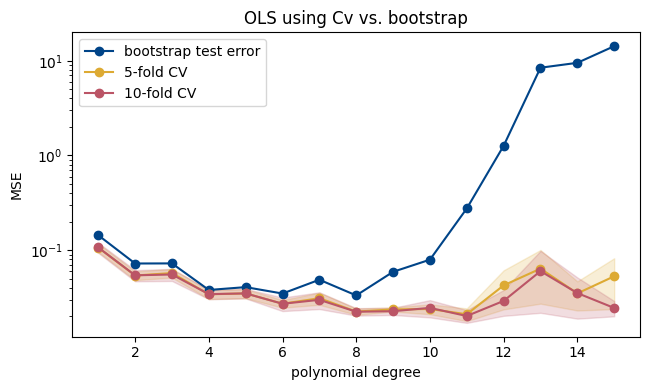

OLS results:
Bootstrap minimum: degree 8, MSE = 0.0334
5-fold CV minimum: degree 11, MSE = 0.0211 ± 0.0032, one-SE choice: degree 8
10-fold CV minimum: degree 11, MSE = 0.0202 ± 0.0031, one-SE choice: degree 8


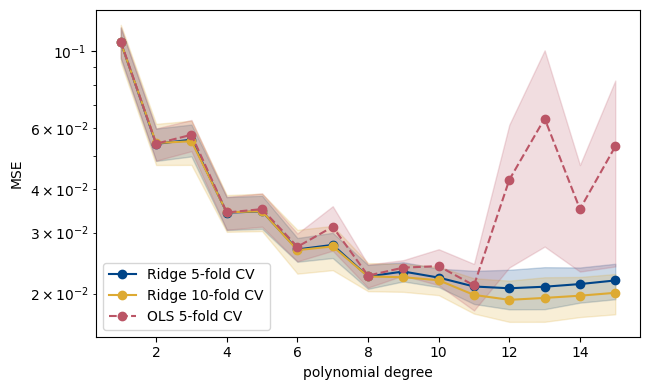

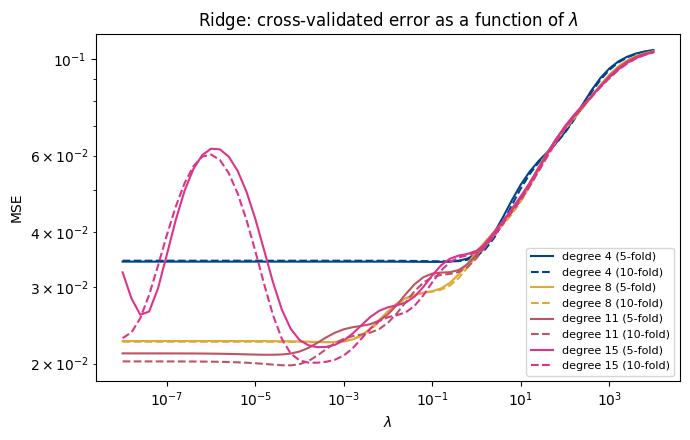


Ridge results:
5-fold CV minimum: degree 12, lambda = 1.584893192461114e-05, MSE = 0.0207 ± 0.0027, one-SE choice: degree 8
10-fold CV minimum: degree 12, lambda = 1e-05, MSE = 0.0192 ± 0.0026, one-SE choice: degree 11
Ridge 5-fold one-SE model: degree 8, lambda = 3.98e-04, MSE = 0.0224 ± 0.0018
Ridge 10-fold one-SE model: degree 11, lambda = 6.31e-05, MSE = 0.0198 ± 0.0023


In [13]:
#one-standard-error rule (Hastie et al., Sec. 7.10)
def one_se_rule(mse, se, degrees):
    """Select the simplest degree whose MSE is within one SE of the minimum."""
    i = np.argmin(mse)
    within = degrees[mse <= mse[i] + se[i]]
    return within.min(), within

# OLS: compare bootstrap test error with 5- and 10-fold CV error
fig, ax = plt.subplots(figsize=(6.6, 4.0))

ax.plot(
    degrees_boot,
    error_boot,
    "o-",
    color=BLUE,
    label="bootstrap test error")

ax.plot(
    degrees_boot,
    mse_ols_5k,
    "o-",
    color=YELLOW,
    label="5-fold CV")
# Show the uncertainty in the CV-MSE as a ±1 SE band
ax.fill_between(degrees_boot, mse_ols_5k - se_ols_5k, mse_ols_5k + se_ols_5k,
                color=YELLOW, alpha=0.2) 

ax.plot(
    degrees_boot,
    mse_ols_10k,
    "o-",
    color=RED,
    label="10-fold CV")
ax.fill_between(degrees_boot, mse_ols_10k - se_ols_10k, mse_ols_10k + se_ols_10k,
                color=RED, alpha=0.2) 

ax.set_yscale("log")
ax.set_xlabel("polynomial degree")
ax.set_ylabel("MSE")
ax.legend()
ax.set_title(f'OLS using Cv vs. bootstrap')

plt.savefig('figures/d_cv_vs_boot.png')
plt.tight_layout()
plt.show()


# Print the minimum OLS errors and the corresponding one-SE choices
print("OLS results:")

print(
    f"Bootstrap minimum: degree "
    f"{degrees_boot[np.argmin(error_boot)]}, "
    f"MSE = {np.min(error_boot):.4f}")

print(
    f"5-fold CV minimum: degree "
    f"{degrees_boot[np.argmin(mse_ols_5k)]}, "
    f"MSE = {np.min(mse_ols_5k):.4f} ± {se_ols_5k[np.argmin(mse_ols_5k)]:.4f}, "      # ± SE
    f"one-SE choice: degree {one_se_rule(mse_ols_5k, se_ols_5k, degrees_boot)[0]}") 

print(
    f"10-fold CV minimum: degree "
    f"{degrees_boot[np.argmin(mse_ols_10k)]}, "
    f"MSE = {np.min(mse_ols_10k):.4f} ± {se_ols_10k[np.argmin(mse_ols_10k)]:.4f}, "  # ± SE
    f"one-SE choice: degree {one_se_rule(mse_ols_10k, se_ols_10k, degrees_boot)[0]}")  

#for each degree, the SE belonging to the best lambda
rows = np.arange(len(degrees_boot))
best_se_rid_5k = se_rid_5k[rows, mse_rid_5k.argmin(axis=1)]
best_se_rid_10k = se_rid_10k[rows, mse_rid_10k.argmin(axis=1)]

# Ridge: minimum CV-MSE over lambda as a function of degree
fig, ax = plt.subplots(figsize=(6.6, 4.0))

ax.plot(
    degrees_boot,
    mse_rid_5k.min(axis=1),
    "o-",
    color=BLUE,
    label="Ridge 5-fold CV")
# ±1 SE band for the best lambda at each degree
ax.fill_between(degrees_boot, mse_rid_5k.min(axis=1) - best_se_rid_5k,
                mse_rid_5k.min(axis=1) + best_se_rid_5k, color=BLUE, alpha=0.2)  

ax.plot(
    degrees_boot,
    mse_rid_10k.min(axis=1),
    "o-",
    color=YELLOW,
    label="Ridge 10-fold CV")
ax.fill_between(degrees_boot, mse_rid_10k.min(axis=1) - best_se_rid_10k,
                mse_rid_10k.min(axis=1) + best_se_rid_10k, color=YELLOW, alpha=0.2)

# Include OLS 5-fold CV as a reference for comparison
ax.plot(
    degrees_boot,
    mse_ols_5k,
    "o--",
    color=RED,
    label="OLS 5-fold CV")
ax.fill_between(degrees_boot, mse_ols_5k - se_ols_5k, mse_ols_5k + se_ols_5k,
                color=RED, alpha=0.2)  

ax.set_yscale("log")
ax.set_xlabel("polynomial degree")
ax.set_ylabel("MSE")
ax.legend()

plt.savefig('figures/d_ridge_of_deg.png')
plt.tight_layout()
plt.show()


# Ridge: investigate how the CV-MSE changes with lambda for selected polynomial degrees
fig, ax = plt.subplots(figsize=(7, 4.5))

for d, color in zip((4, 8, 11, 15), colors):
    i = np.where(degrees_boot == d)[0][0]
    ax.plot(
        lambdas,
        mse_rid_5k[i],
        color=color,
        label=f"degree {d} (5-fold)")

    ax.plot(
        lambdas,
        mse_rid_10k[i],
        "--",
        color=color,
        label=f"degree {d} (10-fold)")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$\lambda$")
ax.set_ylabel("MSE")
ax.set_title(r"Ridge: cross-validated error as a function of $\lambda$")
ax.legend(fontsize=8)

plt.savefig('figures/d_ridge_of_lam.png')
plt.tight_layout()
plt.show()


# Find the overall minimum Ridge CV-MSE and its corresponding polynomial degree and lambda
ridge_5k_idx = np.unravel_index(
    np.argmin(mse_rid_5k),
    mse_rid_5k.shape)

ridge_10k_idx = np.unravel_index(
    np.argmin(mse_rid_10k),
    mse_rid_10k.shape)

print("\nRidge results:")

print(
    f"5-fold CV minimum: degree "
    f"{degrees_boot[ridge_5k_idx[0]]}, "
    f"lambda = {lambdas[ridge_5k_idx[1]]}, "
    f"MSE = {mse_rid_5k[ridge_5k_idx]:.4f} ± {se_rid_5k[ridge_5k_idx]:.4f}, "                           # NEW: ± SE
    f"one-SE choice: degree {one_se_rule(mse_rid_5k.min(axis=1), best_se_rid_5k, degrees_boot)[0]}") 

print(
    f"10-fold CV minimum: degree "
    f"{degrees_boot[ridge_10k_idx[0]]}, "
    f"lambda = {lambdas[ridge_10k_idx[1]]}, "
    f"MSE = {mse_rid_10k[ridge_10k_idx]:.4f} ± {se_rid_10k[ridge_10k_idx]:.4f}, "                          # NEW: ± SE
    f"one-SE choice: degree {one_se_rule(mse_rid_10k.min(axis=1), best_se_rid_10k, degrees_boot)[0]}")  # NEW

# Identify the Ridge model selected by the one-SE rule, including the best lambda for the selected degree
for name, mse, se in [("5-fold", mse_rid_5k, se_rid_5k),
                      ("10-fold", mse_rid_10k, se_rid_10k)]:
    rows = np.arange(len(degrees_boot))
    best_lam = mse.argmin(axis=1)                      # best lambda index for each degree
    best_mse = mse[rows, best_lam]                     # best MSE for each degree
    best_se = se[rows, best_lam]                       # its standard error

    d, _ = one_se_rule(best_mse, best_se, degrees_boot)   # one-SE choice of degree
    i = np.where(degrees_boot == d)[0][0]                 # row of that degree
    j = best_lam[i]                                       # best lambda at that degree

    print(f"Ridge {name} one-SE model: degree {d}, lambda = {lambdas[j]:.2e}, "
          f"MSE = {mse[i, j]:.4f} ± {se[i, j]:.4f}")

### Part e): Writing your own gradient descent code, with analytical gradients and automatic differentiation

Replace now the analytical expressions for the optimal parameters
$\boldsymbol{\theta}$ of OLS and Ridge regression with your own gradient descent
code. In this part we focus only on the simplest gradient descent approach with
a fixed learning rate $\eta$ (see the lectures and exercises of week 37 and
Sections 4.3–4.5 of the lecture notes),

$$
\boldsymbol{\theta}_{k+1} = \boldsymbol{\theta}_k - \eta\,\nabla_{\boldsymbol{\theta}}C(\boldsymbol{\theta}_k).
$$

Compute the gradient of the cost function in two independent ways:

1. **Analytically**, from the expressions you derived in the week-35 exercises,
   that is $\nabla_{\boldsymbol{\theta}}C = \frac{2}{n}\boldsymbol{X}^T(\boldsymbol{X}\boldsymbol{\theta}-\boldsymbol{y})$
   for OLS and the corresponding expression with the extra term
   $2\lambda\boldsymbol{\theta}$ for Ridge (check your normalization
   conventions).
2. By **automatic differentiation** (Section 4.14 of the lecture notes), using
   for example **JAX** (`jax.grad`) or **Autograd**. Write the cost function as
   an ordinary Python function of $\boldsymbol{\theta}$ and let the library
   produce its gradient.

Verify that the two gradients agree to machine precision for OLS and Ridge, and
use both in your gradient descent code. Discuss briefly why automatic
differentiation is neither symbolic nor numerical (finite-difference)
differentiation, and what its cost is relative to one evaluation of the cost
function.

Study and compare your results from parts a) and b) with your gradient descent
approach: do you converge to the closed-form solutions, and how many iterations
does it take? Discuss in particular the role of the learning rate, and relate
the largest learning rate for which the iteration converges to the largest
eigenvalue of the Hessian matrix $\frac{2}{n}\boldsymbol{X}^T\boldsymbol{X}$
(plus $2\lambda\boldsymbol{I}$ for Ridge), see Section 4.5 of the lecture notes.

The cell below shows the minimal version of the automatic-differentiation check
with JAX (install with `pip install jax jaxlib`). Note the 64-bit switch: JAX
defaults to 32-bit floats, which would hide the "machine precision" agreement.

In [14]:
import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)   # 64-bit floats, as in numpy

degree, lmbda = 5, 1e-2
X = design_matrix(x, degree, intercept = False)
theta0 = rng.normal(size=X.shape[1])

def cost_ols(theta, X, y):
    return jnp.mean((y - X @ theta)**2)

def cost_ridge(theta, X, y, lmbda):
    return jnp.mean((y - X @ theta)**2) + lmbda * jnp.sum(theta**2)

# gradients by automatic differentiation (with respect to argument 0 = theta)
grad_ols_ad = jax.grad(cost_ols)
grad_ridge_ad = jax.grad(cost_ridge)

# the same gradients by hand
grad_ols_analytic = 2.0 / len(y) * X.T @ (X @ theta0 - y)
grad_ridge_analytic = grad_ols_analytic + 2.0 * lmbda * theta0

print("OLS   max |AD - analytic| =", np.max(np.abs(grad_ols_ad(theta0, X, y) - grad_ols_analytic)))
print("Ridge max |AD - analytic| =", np.max(np.abs(grad_ridge_ad(theta0, X, y, lmbda) - grad_ridge_analytic)))

# the largest safe learning rate for plain gradient descent: eta < 2 / lambda_max(Hessian)
H = 2.0 / len(y) * X.T @ X
print("eta_max for OLS  =", 2.0 / np.linalg.eigvalsh(H).max())

OLS   max |AD - analytic| = 2.7755575615628914e-17
Ridge max |AD - analytic| = 2.7755575615628914e-17
eta_max for OLS  = 2.2805620250084586


OLS   max |AD - analytic| = 8.881784197001252e-16
Ridge max |AD - analytic| = 8.881784197001252e-16
----------------------------------------------------------------------------------------------------
eta_max OLS   = 0.3596
eta_max Ridge = 0.3583
----------------------------------------------------------------------------------------------------
eta =   0.01:  20000 iterations, |theta OLS   - closed form| =    0.02657616926208136 threshold not reached
eta =   0.01:  20000 iterations, |theta Ridge - closed form| = 0.00017591874797004807 threshold not reached
eta =    0.1:  15155 iterations, |theta OLS   - closed form| =  8.810819535016679e-09  converged
eta =    0.1:   5477 iterations, |theta Ridge - closed form| =  3.180280974060153e-09  converged
eta =    0.3:   5047 iterations, |theta OLS   - closed form| =  8.778872465242883e-09  converged
eta =    0.3:   1821 iterations, |theta Ridge - closed form| =  3.148158011780163e-09  converged
eta =  0.359:   6086 iterations, |theta OLS   - 

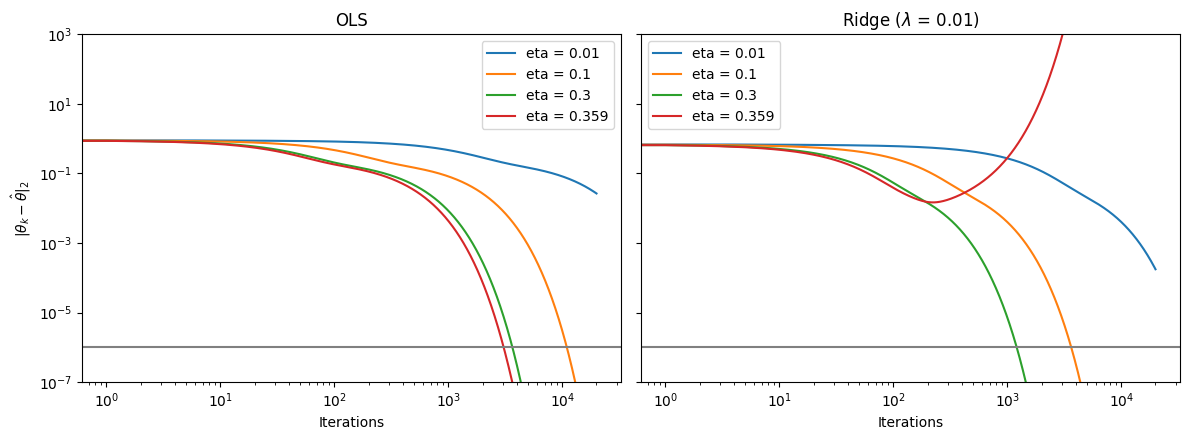

In [15]:
# Your gradient descent code for part e) here (use both gradients!)
num_iters = 20000
tol = 1e-6

# Splitting train- and test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 2026)

X_mean = X_train.mean(axis = 0)
X_std = X_train.std(axis = 0)
X_std[X_std == 0] = 1.0 # Preventing division by 0
X_train_norm = (X_train - X_mean) / X_std
X_test_norm = (X_test - X_mean) / X_std

y_mean = y_train.mean()
y_train_c = y_train - y_mean
y_test_c = y_test - y_mean

n_features = X_train_norm.shape[1]


# ------------------------------------ Analytical gradient
def gradient_OLS(theta, X, y, lam=0.0):
    """Eq. (4.13): the gradient of (1/n)||X theta - y||^2 + lambda theta^T theta."""
    n = len(y)
    return (2.0 / n) * X.T @ (X @ theta - y)

def gradient_Ridge(theta, X, y, lam=0.0):
    """Eq. (4.17): the gradient of (1/n)||X theta - y||^2 + lambda theta^T theta."""
    n = len(y)
    return (2.0 / n) * X.T @ (X @ theta - y)  + 2.0 * lam * theta


# ------------------------------------ Sanity check against the automatic gradients
theta_check = rng.normal(size = n_features)
ad_OLS = grad_ols_ad(theta_check, X_train_norm, y_train_c)
ad_Ridge = grad_ridge_ad(theta_check, X_train_norm, y_train_c, lmbda = lmbda)
an_OLS = gradient_OLS(theta_check, X_train_norm, y_train_c)
an_Ridge = gradient_Ridge(theta_check, X_train_norm, y_train_c, lam = lmbda)

# Do they agree to machine precision?
print("OLS   max |AD - analytic| =", np.max(np.abs(ad_OLS - an_OLS)))
print("Ridge max |AD - analytic| =", np.max(np.abs(ad_Ridge - an_Ridge)))


# ------------------------------------ Plain gradient descent for OLS and Ridge
def gradient_descent(X, y, eta, lam=0.0, theta0=None):
    """Plain gradient descent, Eq. (4.15). Returns the iterates and the number of steps."""
    
    # Initialize weights for gradient descent
    theta = theta0.copy() if theta0 is not None else np.zeros(n_features)
    history = [theta.copy()]

    # Gradient descent loop
    for t in range(num_iters):
        # Compute gradients for OLS and Ridge
        grad = gradient_Ridge(theta, X, y, lam = lam) if lam > 0 else gradient_OLS(theta, X, y)
        # Update parameters theta
        theta = theta - eta * grad
        history.append(theta.copy())

        if np.linalg.norm(grad) < 1e-10: # Near a stationary point
            break
    return np.array(history), t+1


# ------------------------------------ Closed form solutions OLS and Ridge
def closed_form(X, y, lam):
    n, p = X.shape
    return np.linalg.solve(X.T @ X + n * lam * np.eye(p), X.T @ y)

theta_hat_OLS = closed_form(X_train_norm, y_train_c, lam = 0.0)
theta_hat_ridge = closed_form(X_train_norm, y_train_c, lam = lmbda)


# ------------------------------------ Finding the largest stable learning rate (eta_max)
H_OLS = 2 / len(y_train_c) * X_train_norm.T @ X_train_norm
H_ridge = (2 / len(y_train_c) * X_train_norm.T @ X_train_norm) + (2.0 * lmbda * np.eye(n_features))

# Finding the max values
eta_max_OLS = 2.0 / np.linalg.eigvalsh(H_OLS).max()
eta_max_ridge = 2.0 / np.linalg.eigvalsh(H_ridge).max()
print('-'*100)
print(f'eta_max OLS   = {eta_max_OLS:.4f}')
print(f'eta_max Ridge = {eta_max_ridge:.4f}')


# ------------------------------------ Comparing gradient descent for OLS and Ridge to the closed form solution
# ------------------------------------ Plotting the deviations
print('-'*100)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for eta in (0.01, 0.1, 0.3, 0.359): # Testing different learning rates
    with np.errstate(all = 'ignore'):
        history_theta_OLS, iteration_t_OLS = gradient_descent(X_train_norm, y_train_c, eta, lam=0.0, theta0=None)
        history_theta_ridge, iteration_t_ridge = gradient_descent(X_train_norm, y_train_c, eta, lam=lmbda, theta0=None)

        theta_final_OLS = history_theta_OLS[-1]
        theta_final_ridge = history_theta_ridge[-1]

    # Finding the magnitude of the deviations
    err_OLS = np.linalg.norm(theta_final_OLS - theta_hat_OLS)
    err_ridge = np.linalg.norm(theta_final_ridge - theta_hat_ridge)

    # Do we reach a precision within the tolerance-threshold?

    status_OLS = 'diverged (overflow)' if not np.all(np.isfinite(err_OLS)) else ('converged' if iteration_t_OLS < num_iters else 'threshold not reached')
    status_ridge = 'diverged (overflow)' if not np.all(np.isfinite(err_ridge)) else ('converged' if iteration_t_ridge < num_iters else 'threshold not reached')
    
    
    print(f'eta = {eta:>6}: {iteration_t_OLS:>6} iterations, |theta OLS   - closed form| = {err_OLS:>22} {status_OLS:>10}')
    print(f'eta = {eta:>6}: {iteration_t_ridge:>6} iterations, |theta Ridge - closed form| = {err_ridge:>22} {status_ridge:>10}')

    distance_OLS = np.linalg.norm(history_theta_OLS - theta_hat_OLS, axis=1)
    distance_ridge = np.linalg.norm(history_theta_ridge - theta_hat_ridge, axis=1)
    
    axes[0].plot( distance_OLS, label = f'eta = {eta}')
    axes[1].plot( distance_ridge, label = f'eta = {eta}')

for ax, title in zip(axes, ['OLS', fr'Ridge ($\lambda$ = {lmbda})']):
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_ylim(1e-7, 1e3)
    ax.set_xlabel(r'Iterations')
    ax.set_title(title)
    ax.legend(frameon = True)

axes[0].axhline(tol, color = 'grey', label = 'threshold')
axes[1].axhline(tol, color = 'grey', label = 'threshold')
axes[0].set_ylabel(r'$|\theta_k - \hat{\theta}|_2$')

plt.tight_layout()
plt.savefig('figures/plain_GD.png')
plt.show()



### Part f): Including momentum and more advanced ways to update the learning rate

We keep our focus on OLS and Ridge regression and update our gradient descent
code by including **momentum**, **AdaGrad**, **RMSprop** and **Adam** as methods
for iteratively updating the learning rate (Sections 4.6 and 4.8–4.11 of the
lecture notes; the lectures of weeks 37 and 38 contain several examples on how
to implement these methods). You are free to use either the analytical or the
automatically differentiated gradient here — the update rules do not care where
the gradient comes from.

Discuss the results and compare the different methods applied to the
one-dimensional Runge function, for example in terms of the number of iterations
needed to reach a given accuracy relative to the closed-form solution, and in
terms of their sensitivity to the choice of the (initial) learning rate.

In [16]:
# Your code for part f) here

# ------------------------------------ A single update steps for all methods
def optimiser_step(method, theta, g, state, t, eta, beta=0.9, rho=0.99,
                   beta1=0.9, beta2=0.999, eps=1e-8):
    """One update of theta from the gradient g at step t = 1, 2, ...; state carries the running quantities."""
    if method == "plain":                                    # Eq. (4.10)
        return theta - eta * g, state
    if method == "momentum":                                 # Eq. (4.28)
        state["v"] = v = beta * state.get("v", 0.0) + eta * g
        return theta - v, state
    if method == "adagrad":                                  # Eqs. (4.42) and (4.45)
        state["r"] = r = state.get("r", 0.0) + g * g
        return theta - eta * g / (np.sqrt(r) + eps), state
    if method == "rmsprop":                                  # Eqs. (4.47) and (4.48)
        state["r"] = r = rho * state.get("r", 0.0) + (1.0 - rho) * g * g 
        return theta - eta * g / (np.sqrt(r) + eps), state
    if method == "adam":                                     # Eqs. (4.51), (4.52), (4.54), (4.55)
        state["m"] = m = beta1 * state.get("m", 0.0) + (1.0 - beta1) * g
        state["r"] = r = beta2 * state.get("r", 0.0) + (1.0 - beta2) * g * g
        m_hat, r_hat = m / (1.0 - beta1**t), r / (1.0 - beta2**t)
        
        return theta - (eta * m_hat / (np.sqrt(r_hat) + eps)), state
    raise ValueError(f"unknown method {method}")


# ------------------------------------ Running the whole optimization for given method(s)
def optimise(grad, theta0, method, eta, num_iters, **kw):
    """Full-gradient loop; returns all iterates and the number of steps taken."""
    theta, state = np.array(theta0, dtype=float), {}
    history = [theta.copy()]

    for t in range(1, num_iters + 1):
        g = grad(theta)

        theta, state = optimiser_step(method, theta, g, state, t, eta, **kw)
        history.append(theta.copy())
        
        if np.linalg.norm(g) < 1e-10: #near a stationary point
            break
    return np.array(history), t



# ------------------------------------ Finding required iterations to reach threshold
def iterations(history, theta_hat, threshold=1e-6):
    distance = np.linalg.norm(history - theta_hat, axis=1)
    hit = np.where(distance < threshold)[0] 
    return (hit[0], None) if len(hit) > 0 else (None, distance[-1]) # (hit) > 0 else (None, distance[-1])



# ------------------------------------ Trying all optimization methods
# ------------------------------------ Finding the amount of required iterations
def run_methods(grad, theta_hat, eta_plain, eta_momentum, label, num_iters = num_iters):
    theta0 = np.zeros(n_features)
    print('-'*80)
    print(f'For {label}')
    print('-'*80)
    for method, eta in [('plain', eta_plain), ('momentum', eta_momentum)]: # plain and momentum with upper limit learning rate
        history, _ = optimise(grad, theta0, method, eta, num_iters = num_iters)
        n_iter, final_dist = iterations(history, theta_hat)
        status = f'{n_iter:>5} iterations' if n_iter is not None else f'  --  did not reach threshold (final = {final_dist:.4f})'
        print(f'{method:>10} (eta = {eta:.2f}) : {status}')

    for method in ('adagrad', 'rmsprop', 'adam'): # two fixed learning rates
        for eta in (0.01, 0.1):
            history, _ = optimise(grad, theta0, method, eta, num_iters = num_iters)
            n_iter, final_dist = iterations(history, theta_hat)
            status = f'{n_iter:>5} iterations' if n_iter is not None else f'  --  did not reach threshold (final = {final_dist:.4f})'
            print(f'{method:>10} (eta = {eta:.2f}) : {status}')



# Analytical gradients
grad_OLS = lambda theta: gradient_OLS(theta, X_train_norm, y_train_c)
grad_ridge = lambda theta: gradient_Ridge(theta, X_train_norm, y_train_c, lam = lmbda)

# Computing the upper limit of learning rate (eta) for plain and momentum (OLS + Ridge)
# Based on eta_max
beta_momentum = 0.9

eta_plain_OLS = 0.9 * eta_max_OLS 
eta_plain_ridge = 0.9 * eta_max_ridge

eta_momentum_OLS = 0.9 * eta_max_OLS * (1.0 + beta_momentum)
eta_momentum_ridge = 0.9 * eta_max_ridge * (1.0 + beta_momentum)

run_methods(grad_OLS, theta_hat_OLS, eta_plain_OLS, eta_momentum_OLS, 'OLS')
run_methods(grad_ridge, theta_hat_ridge, eta_plain_ridge, eta_momentum_ridge, f'Ridge (lambda = {lmbda})')



--------------------------------------------------------------------------------
For OLS
--------------------------------------------------------------------------------
     plain (eta = 0.32) :  3390 iterations
  momentum (eta = 0.61) :   246 iterations
   adagrad (eta = 0.01) :   --  did not reach threshold (final = 0.0003)
   adagrad (eta = 0.10) :  5827 iterations
   rmsprop (eta = 0.01) :   --  did not reach threshold (final = 0.0112)
   rmsprop (eta = 0.10) :   --  did not reach threshold (final = 0.1118)
      adam (eta = 0.01) :   677 iterations
      adam (eta = 0.10) :   517 iterations
--------------------------------------------------------------------------------
For Ridge (lambda = 0.01)
--------------------------------------------------------------------------------
     plain (eta = 0.32) :  1127 iterations
  momentum (eta = 0.61) :   230 iterations
   adagrad (eta = 0.01) :   --  did not reach threshold (final = 0.0000)
   adagrad (eta = 0.10) :  1943 iterations
   rms

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2803: RuntimeWarning: overflow encountered in multiply
  s = (x.conj() * x).real
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2804: RuntimeWarning: overflow encountered in reduce
  return sqrt(add.reduce(s, axis=axis, keepdims=keepdims))


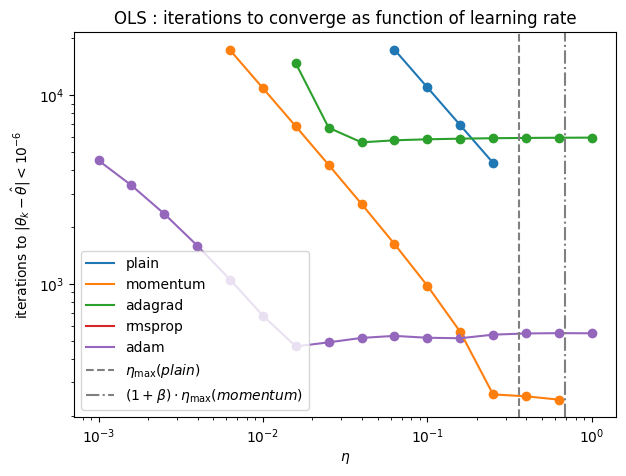

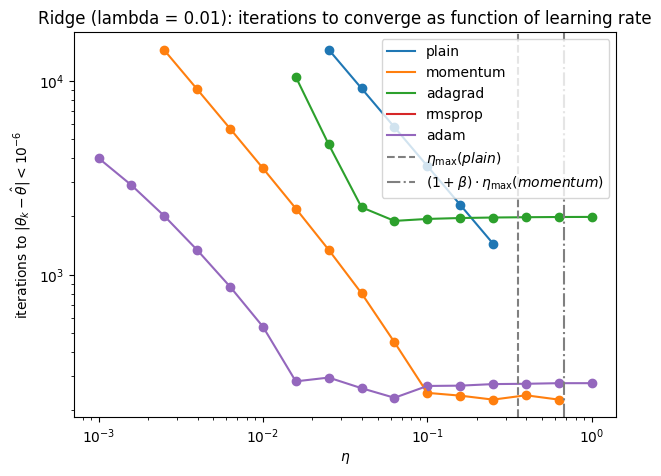

In [17]:
eta_vals = np.logspace(-3, 0, 16) # logarithmic grid of testing values
methods = ['plain', 'momentum', 'adagrad', 'rmsprop', 'adam']

# ------------------------------------ Checking method-sensititivy to the initial learning rate
# ------------------------------------ (Sorting fastest to slowest method for all eta)
def eta_sense(grad, theta_hat, eta_max, label, num_iters = num_iters):
    theta0 = np.zeros(n_features)
    results = {method: [] for method in methods}

    for method in methods: 
        for eta in eta_vals:
            with np.errstate(over = 'ignore', invalid = 'ignore'):
                history, _ = optimise(grad, theta0, method, eta, num_iters = num_iters)
            n_iter, _ = iterations(history, theta_hat)
            results[method].append(n_iter if n_iter is not None else np.nan)


    plt.figure(figsize = (7, 5))
    for method in methods:
        n_iterations = np.array(results[method], dtype = float)
        plt.plot(eta_vals, n_iterations, label = method)
        plt.scatter(eta_vals, n_iterations)

    plt.axvline(eta_max, color='grey', linestyle="dashed", label=r'$\eta_\mathrm{max} (plain)$')                          # peak for plain
    plt.axvline(eta_max * (1 + beta_momentum), color="grey", linestyle="dashdot", label=r"$(1+\beta) \cdot \eta_\mathrm{max} (momentum)$")   # peak for momentum (beta = 0.9)
    plt.title(f'{label}: iterations to converge as function of learning rate')
    plt.xlabel(r'$\eta$')
    plt.ylabel(r'iterations to $|\theta_k - \hat{\theta}| < 10^{-6}$')
    plt.xscale('log')
    plt.yscale('log')
    plt.legend()
    plt.savefig(f'figures/iterations_to_converge_{label}.png')
    plt.show()

    return results


results_OLS = eta_sense(grad_OLS, theta_hat_OLS, eta_max_OLS, 'OLS ')
results_ridge = eta_sense(grad_ridge, theta_hat_ridge, eta_max_ridge, f'Ridge (lambda = {lmbda})')

### Part g): Writing our own code for Lasso regression

Lasso regression (Section 3.9 of the lecture notes, and the lectures of weeks 35
and 36) represents our first encounter with a machine learning method which
cannot be solved through analytical expressions (as in OLS and Ridge
regression). Use the gradient descent methods you developed in parts e) and f)
to solve the Lasso optimization problem.

The $\ell_1$ penalty $\lambda\|\boldsymbol{\theta}\|_1$ is not differentiable
at $\theta_j=0$. Discuss how you could handle this: what does your automatic
differentiation tool return for the derivative of $|\theta|$ at zero, and is
that a valid subgradient? Based on the gradient, write your own code for Lasso
regression.

You can compare your results with the functionalities of **Scikit-Learn**; be
careful with the different conventions for the penalty parameter (`alpha`) and
the normalization of the cost function discussed in the week-35 and week-36
Tuesday sessions.

Discuss (critically) your results for the Runge function from OLS, Ridge and
Lasso regression using the various gradient descent approaches.

jax.grad(jnp.abs)(0.0) = 1.0
jax.grad(jnp.abs)(-0.3) = -1.0  jax.grad(jnp.abs)(0.3) = 1.0
plain:
  theta = [ 0.01785337 -0.5574787   0.02731361  0.36071366  0.01606272]
  distance to Scikit-Learn = 0.02681758646636961

momentum:
  theta = [-1.33670516e-02 -5.56510067e-01  4.93622582e-04  3.64491679e-01
 -1.05331262e-02]
  distance to Scikit-Learn = 0.02338758637593666

adagrad:
  theta = [ 1.34814884e-04 -5.54346905e-01  1.56712762e-02  3.60127250e-01
 -4.98501530e-06]
  distance to Scikit-Learn = 0.00019602290624090837

rmsprop:
  theta = [ 0.01184899 -0.55921001  0.01016263  0.35508755  0.00868344]
  distance to Scikit-Learn = 0.01722308642782866

adam:
  theta = [ 3.59211720e-04 -5.52702015e-01  1.56030269e-02  3.59519264e-01
  2.66827399e-04]
  distance to Scikit-Learn = 0.0018769344160999087

plain:
  Lasso cost = 0.04269674962891548
momentum:
  Lasso cost = 0.0425034976894796
adagrad:
  Lasso cost = 0.040670364788461554
rmsprop:
  Lasso cost = 0.04105183878870604
adam:
  Lasso co

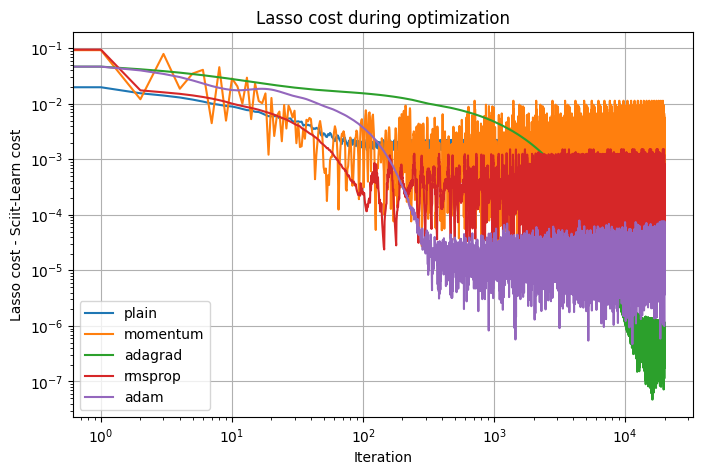

In [18]:
# What does AD say about d|theta|/dtheta at theta = 0?  (Discuss whether this is a valid subgradient.)
print("jax.grad(jnp.abs)(0.0) =", jax.grad(jnp.abs)(0.0))
print("jax.grad(jnp.abs)(-0.3) =", jax.grad(jnp.abs)(-0.3), " jax.grad(jnp.abs)(0.3) =", jax.grad(jnp.abs)(0.3))

# Your Lasso code for part g) here

# Gradient/subgradient of the Lasso cost:
# the OLS gradient is combined with the subgradient of the L1 penalty.
def gradient_lasso(theta, X, y, lam):
    return gradient_OLS(theta, X, y) + lam * np.sign(theta)

# Define the Lasso gradient using the training data
grad_lasso = lambda theta: gradient_lasso(
    theta, X_train_norm, y_train_c, lmbda)

# Learning rates for the plain gradient descent and momentum methods.
eta_plain_lasso = 0.9 * eta_max_OLS
eta_momentum_lasso = 0.9 * eta_max_OLS * (1 + beta_momentum)

# Initialize all model parameters at zero
theta0 = np.zeros(n_features)

# Run the Lasso optimization with each optimization method
lasso_results = {}

for method in methods:

    if method == "plain":
        eta = eta_plain_lasso

    elif method == "momentum":
        eta = eta_momentum_lasso

    else:
        # Same learning rates as used in Part f
        eta = 0.01

    history, n_iters = optimise(
        grad_lasso,
        theta0,
        method,
        eta,
        num_iters=num_iters)

    # Store the optimization history, final parameters, and number of iterations
    lasso_results[method] = {
        "history": history,
        "theta": history[-1],
        "iterations": n_iters}

# Fit the corresponding Lasso model using scikit-learn as a reference solution.
# sklearn uses a factor 1/2 in its objective, => alpha = lambda / 2.
lasso_sklearn = Lasso(
    alpha=lmbda / 2,
    fit_intercept=False,
    max_iter=100000,
    tol=1e-10)

lasso_sklearn.fit(X_train_norm, y_train_c)
theta_lasso_sklearn = lasso_sklearn.coef_


# Compare methods with Scikit-Learn
for method in methods:
    theta_lasso = lasso_results[method]["theta"]
    distance = np.linalg.norm(
        theta_lasso - theta_lasso_sklearn)
    
    print(f"{method}:")
    print("  theta =", theta_lasso)
    print("  distance to Scikit-Learn =", distance)
    print()

# Define the Lasso cost function used to evaluate the solutions
def cost_lasso(theta, X, y, lam):
    return (
        np.mean((y - X @ theta)**2)
        + lam * np.sum(np.abs(theta)))

# Calculate the final Lasso cost for each optimization method
for method in methods:
    theta_lasso = lasso_results[method]["theta"]
    cost = cost_lasso(
        theta_lasso,
        X_train_norm,
        y_train_c,
        lmbda)

    print(f"{method}:")
    print("  Lasso cost =", cost)

# Use the scikit-learn solution as a reference for the minimum cost
cost_min = cost_lasso(theta_lasso_sklearn, 
                      X_train_norm, 
                      y_train_c, 
                      lmbda)


# Plot the convergence of the Lasso cost for each optimization method
plt.figure(figsize=(8, 5))

for method in methods:
    history = lasso_results[method]["history"]
    # Calculate the Lasso cost at each iteration
    costs = [
        cost_lasso(theta, X_train_norm, y_train_c, lmbda)
        for theta in history]
    # Plot the difference from the scikit-learn reference cost
    plt.plot(np.array(costs) - cost_min, label=method)

plt.xscale('log')  
plt.yscale('log')
plt.xlabel("Iteration")
plt.ylabel("Lasso cost - Sciit-Learn cost")
plt.title("Lasso cost during optimization")
plt.legend()
plt.grid()
plt.savefig('figures/g_lasso_cost.png')
plt.show()


In [19]:
#Coefficient table: OLS, Ridge and Lasso
rows = {
    "OLS": theta_hat_OLS,
    "Ridge": theta_hat_ridge,
    "Lasso (sklearn)": theta_lasso_sklearn,
}
for method in methods:                                    # gradient-descent Lasso runs
    rows[f"Lasso ({method})"] = lasso_results[method]["theta"]

header = f'{"Model":<18}' + "".join(f'{"θ_" + str(j+1):>11}' for j in range(n_features)) + f'{"zeros":>7}'
print(header)
print("-" * len(header))
for name, theta in rows.items():
    print(f"{name:<18}" + "".join(f"{t:>11.2e}" for t in theta) + f"{np.sum(theta == 0):>7d}")


# Print for latex 

"""
def make_ltx(t):
    if t == 0:
        return r"$\mathbf{0}$"                            # exact zero
    if abs(t) < 1e-2:
        mant, exp = f"{t:.1e}".split("e")
        return rf"${mant}\cdot10^{{{int(exp)}}}$"        # small values in scientific notation
    return f"${t:.3f}$"

for name, theta in rows.items():
    print(f"{name} & " + " & ".join(make_ltx(t) for t in theta) + rf" & {np.sum(theta == 0)} \\")

"""

Model                     θ_1        θ_2        θ_3        θ_4        θ_5  zeros
--------------------------------------------------------------------------------
OLS                 -6.58e-02  -6.95e-01   2.28e-01   4.94e-01  -1.41e-01      0
Ridge               -2.02e-02  -5.66e-01   9.09e-02   3.70e-01  -5.35e-02      0
Lasso (sklearn)      0.00e+00  -5.54e-01   1.58e-02   3.60e-01   0.00e+00      2
Lasso (plain)        1.79e-02  -5.57e-01   2.73e-02   3.61e-01   1.61e-02      0
Lasso (momentum)    -1.34e-02  -5.57e-01   4.94e-04   3.64e-01  -1.05e-02      0
Lasso (adagrad)      1.35e-04  -5.54e-01   1.57e-02   3.60e-01  -4.99e-06      0
Lasso (rmsprop)      1.18e-02  -5.59e-01   1.02e-02   3.55e-01   8.68e-03      0
Lasso (adam)         3.59e-04  -5.53e-01   1.56e-02   3.60e-01   2.67e-04      0


<>:22: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:22: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/var/folders/y1/4fm9cgtd2mq2322hqqpz5ptc0000gn/T/ipykernel_25657/2525049690.py:22: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  return r"$\mathbf{0}$"                            # exact zero


'\ndef make_ltx(t):\n    if t == 0:\n        return r"$\\mathbf{0}$"                            # exact zero\n    if abs(t) < 1e-2:\n        mant, exp = f"{t:.1e}".split("e")\n        return rf"${mant}\\cdot10^{{{int(exp)}}}$"        # small values in scientific notation\n    return f"${t:.3f}$"\n\nfor name, theta in rows.items():\n    print(f"{name} & " + " & ".join(make_ltx(t) for t in theta) + rf" & {np.sum(theta == 0)} \\")\n\n'

Test MSE:
OLS:    0.03663059935633522
Ridge:  0.0392738036635694
Lasso:  0.03944940881299753


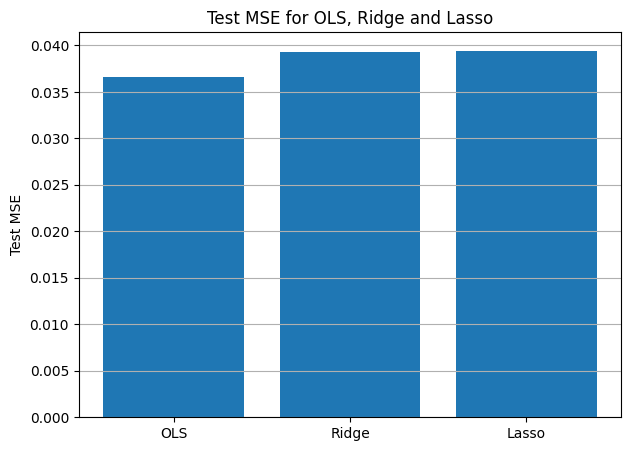

In [20]:
# Calculate test-set predictions and MSE for each model

# OLS
y_pred_OLS = X_test_norm @ theta_hat_OLS
mse_OLS = mean_squared_error(y_test_c, y_pred_OLS)

# Ridge
y_pred_ridge = X_test_norm @ theta_hat_ridge
mse_ridge = mean_squared_error(y_test_c, y_pred_ridge)

# Lasso (scikit)
y_pred_lasso = X_test_norm @ theta_lasso_sklearn
mse_lasso = mean_squared_error(y_test_c, y_pred_lasso)

# Print the test MSE for comparison
print("Test MSE:")
print("OLS:   ", mse_OLS)
print("Ridge: ", mse_ridge)
print("Lasso: ", mse_lasso)

# Compare the test MSE of the three models in a bar plot
models = ["OLS", "Ridge", "Lasso"]
mse = [mse_OLS, mse_ridge, mse_lasso]

plt.figure(figsize=(7, 5))
plt.bar(models, mse)

plt.ylabel("Test MSE")
plt.title("Test MSE for OLS, Ridge and Lasso")
plt.grid(axis="y")
plt.savefig('figures/g_test_mse_cv.png')
plt.show()

### Part h): Stochastic gradient descent

Our last gradient step is to include stochastic gradient descent (Section 4.7
of the lecture notes) using the same methods to update the learning rates as in
parts e)–g). Split the training data into mini-batches, loop over epochs, and
study the dependence on the mini-batch size, the number of epochs and the
learning-rate schedule. Compare and discuss your results with and without
stochastic gradient descent and give a critical assessment of the various
methods — both in terms of the final accuracy relative to the closed-form
solutions of parts a) and b), and in terms of computational cost.

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2803: RuntimeWarning: overflow encountered in multiply
  s = (x.conj() * x).real


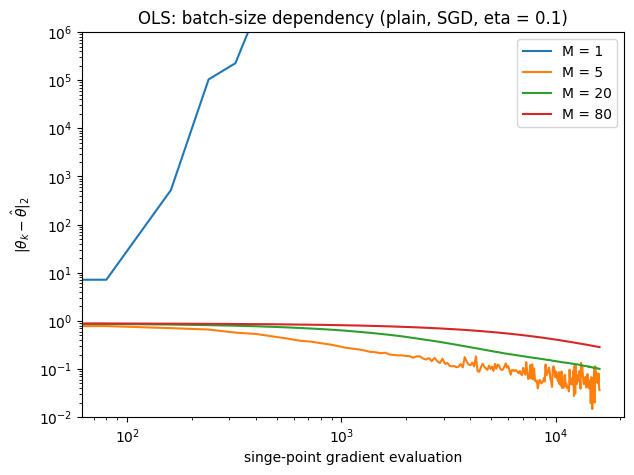

In [21]:
# Your code for part h) here

def make_batches(n, batch_size, rng):
    """Shuffle the indices and split them into minibatches."""
    idx = rng.permutation(n)
    return [idx[i:i + batch_size] for i in range(0, n, batch_size)]


def step_length(t, t0, t1):
    """The schedule of Eq. (4.40)."""
    return t0 / (t + t1)


# Using our own gradient descent for OLS and Ridge
def grad_batch(theta, X, y, lam):
    return gradient_Ridge(theta, X, y, lam = lam) if lam > 0 else gradient_OLS(theta, X, y)


# Using the optimiser methods on the minibatch
# Replacing const. eta with schedule
def sgd(X, y, method="plain", n_epochs=200, batch_size=5, eta=0.1, schedule=None, lam=0.0, seed=2026, **kw):
    """Minibatch SGD, Eq. (4.34), with any optimiser from part f. schedule=(t0, t1) replaces a constant eta by Eq. (4.40).
    Returns the iterate after every epoch."""
    rng = np.random.default_rng(seed)
    n, p = X.shape
    theta, state, t = np.zeros(p), {}, 0
    history = [theta.copy()]

    for epoch in range(n_epochs):
        for batch in make_batches(n, batch_size, rng):
            t += 1
            g = grad_batch(theta, X[batch], y[batch], lam)     # the gradient of the cost on this minibatch
            eta_t = eta if schedule is None else step_length(t, schedule[0], schedule[1])   # constant, or the schedule
            theta, state = optimiser_step(method, theta, g, state, t, eta_t, **kw)
        history.append(theta.copy())
    return np.array(history), eta_t

def cost_axis(history, n):
    return np.arange(len(history)) * n


# ------------------------------------ Testing the dependenc of the mini-batch size for OLS and plain SGD
n_train = X_train_norm.shape[0]
batch_sizes = [1, 5, 20 ,n_train] # M = n_train is the full-batch limit

plt.figure(figsize = (7, 5))
for M in batch_sizes: # go through every batch size
    history, eta_t = sgd(X_train_norm, y_train_c, batch_size=M)
    dist = np.linalg.norm(history - theta_hat_OLS, axis = 1)
    plt.loglog(cost_axis(history, n_train), dist, label = f'M = {M}')

plt.ylim(1e-2, 1e6)
plt.xlabel('singe-point gradient evaluation')
plt.ylabel(r'$| \theta_k - \hat{\theta} |_2$')
plt.title(f'OLS: batch-size dependency (plain, SGD, eta = 0.1)') # const eta since shedule = None
plt.legend()
plt.savefig('figures/batch_size_scan.png')
plt.show()

         problem |                  learning rate |       ep10 |       ep50 |      ep200 |     ep1000
----------------------------------------------------------------------------------------------------
             OLS |                 const. eta=0.1 |   3.44e-01 |   1.20e-01 |   3.64e-02 |   6.17e-02
             OLS |      schedule (t0,t1)=(10,100) |   4.73e-01 |   2.62e-01 |   1.86e-01 |   1.47e-01
 Ridge(lam=0.01) |                 const. eta=0.1 |   1.66e-01 |   4.25e-02 |   3.30e-02 |   5.74e-02
 Ridge(lam=0.01) |      schedule (t0,t1)=(10,100) |   2.73e-01 |   9.57e-02 |   4.07e-02 |   2.02e-02


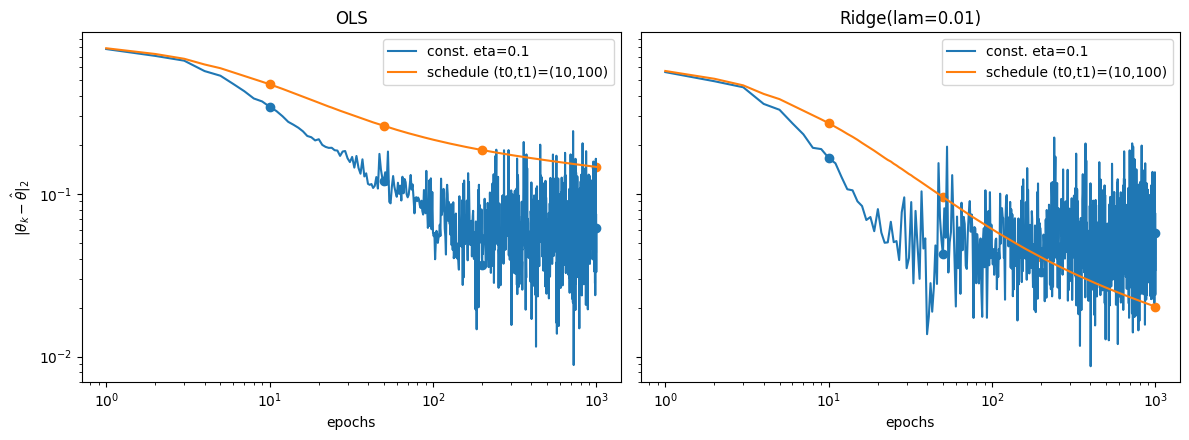

In [22]:
# ------------------------------------ Testing the dependence on the number of epochs (plain SGD, M=5)
n_epochs_max = 1000
epoch_list = [10, 50, 200, 1000]
epochs_runs = [('const. eta=0.1', 0.1, None), ('schedule (t0,t1)=(10,100)', 0.1, (10,100))]
epoch_problems = [('OLS', theta_hat_OLS, 0.0), (f'Ridge(lam={lmbda})', theta_hat_ridge, lmbda)]

fig, axes = plt.subplots(1, 2, figsize = (12, 4.5), sharey = True)
print(f'{"problem":>16} | {"learning rate":>30} | ' + ' | '.join(f'{"ep"+str(k):>10}' for k in epoch_list))
print('-'*100)

# computing for both OLS and Ridge
for (label, theta_hat_, lam_), ax in zip(epoch_problems, axes):
    
    # testing different amount of epochs, learning rates and schedules
    for run_label, eta, schedule in epochs_runs:
        history, _ = sgd(X_train_norm, y_train_c, n_epochs = n_epochs_max, eta = eta, schedule = schedule, lam = lam_)
        dist = np.linalg.norm(history - theta_hat_, axis = 1)

        ax.plot(np.arange(1, len(dist)), dist[1:], label = run_label) # skip epoch 0
        ax.scatter(epoch_list, dist[epoch_list]) # marking the tested epoch values from epoch_list
        print(f'{label:>16} | {run_label:>30} | ' + ' | '.join(f'{dist[k]:>10.2e}' for k in epoch_list))

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('epochs')
    ax.set_title(label)
    ax.legend()

axes[0].set_ylabel(r'$| \theta_k - \hat{\theta} |_2$')
plt.tight_layout()
plt.savefig('figures/schedule_scan_1.png')
plt.show()


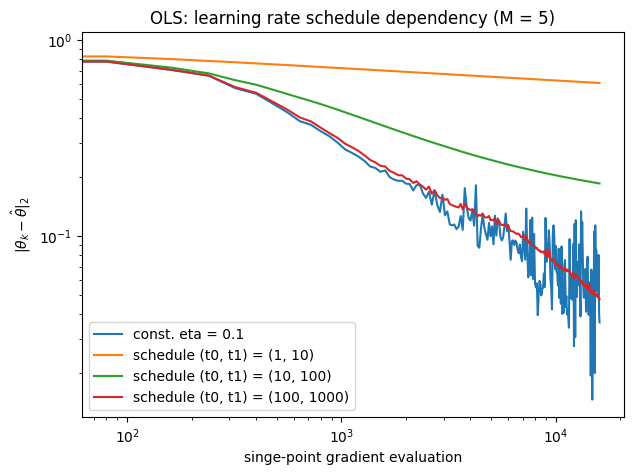

In [23]:
# ------------------------------------ Checking dependence on learning rate schedule (OLS, M=5)
plt.figure(figsize = (7, 5))
for eta, schedule, label in [(0.1, None, 'const. eta = 0.1'),
                             (0.1, (1, 10), 'schedule (t0, t1) = (1, 10)'),
                             (0.1, (10, 100), 'schedule (t0, t1) = (10, 100)'),
                             (0.1, (100, 1000), 'schedule (t0, t1) = (100, 1000)')]:

    history, eta_t = sgd(X_train_norm, y_train_c, eta = eta, schedule = schedule)
    dist = np.linalg.norm(history - theta_hat_OLS, axis = 1)
    plt.loglog(cost_axis(history, n_train), dist, label = label)

plt.xlabel('singe-point gradient evaluation')
plt.ylabel(r'$| \theta_k - \hat{\theta} |_2$')
plt.title(f'OLS: learning rate schedule dependency (M = 5)') 
plt.legend()
plt.savefig('figures/schedule_scan_2.png')
plt.show()


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2804: RuntimeWarning: overflow encountered in reduce
  return sqrt(add.reduce(s, axis=axis, keepdims=keepdims))


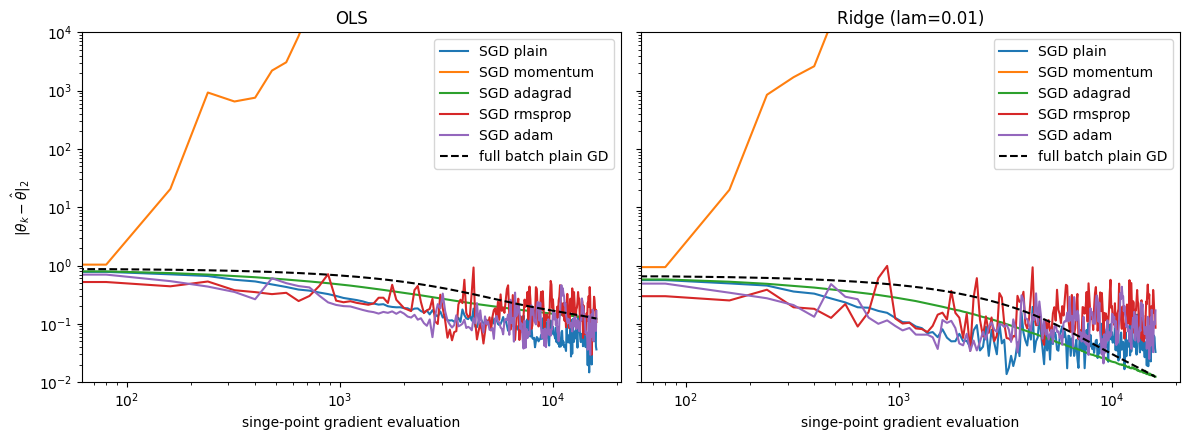

             problem |               method | final |theta - theta_hat| | grad. evals
----------------------------------------------------------------------------------------------------
                 OLS |            SGD plain |                3.6413e-02 |      16000
                 OLS |         SGD momentum |                       inf |      16000
                 OLS |          SGD adagrad |                1.2178e-01 |      16000
                 OLS |          SGD rmsprop |                1.0765e-01 |      16000
                 OLS |             SGD adam |                1.6582e-01 |      16000
                 OLS |  full batch plain GD |                1.2321e-01 |      16000
    Ridge (lam=0.01) |            SGD plain |                3.2965e-02 |      16000
    Ridge (lam=0.01) |         SGD momentum |                       inf |      16000
    Ridge (lam=0.01) |          SGD adagrad |                1.2395e-02 |      16000
    Ridge (lam=0.01) |          SGD rmsprop |   

In [24]:
# ------------------------------------ SGD with all optimizers
n_epochs_cmp = 200
configurations = [('plain', 0.1), ('momentum', 0.1), ('adagrad', 0.1), ('rmsprop', 0.1), ('adam', 0.1)]
#what about momentum eta = 0.01

fig, axes = plt.subplots(1, 2, figsize = (12, 4.5), sharey = True)
problems = {'OLS': (theta_hat_OLS, 0.0, eta_max_OLS, axes[0]), f'Ridge (lam={lmbda})': (theta_hat_ridge, lmbda, eta_max_ridge, axes[1])}
final_accuracy = {} # (label, method) = final dist, grad. evaluations

for label, (theta_hat_, lam_, eta_max_, ax) in problems.items():
     
    for method, eta in configurations:
        history, _ = sgd(X_train_norm, y_train_c, method = method, n_epochs = n_epochs_cmp, eta = eta, lam = lam_)
        dist = np.linalg.norm(history - theta_hat_, axis = 1)
        ax.plot(cost_axis(history, n_train), dist, label = f'SGD {method}')
        final_accuracy[(label, f'SGD {method}')] = (dist[-1], cost_axis(history, n_train)[-1])

    # full-batch plain GD
    full_grad = (lambda theta: gradient_Ridge(theta, X_train_norm, y_train_c, lam = lam_)) if lam_ > 0 else (lambda theta: gradient_OLS(theta, X_train_norm, y_train_c))
    full_history, _ = optimise(full_grad, np.zeros(n_features), 'plain', 0.9 * eta_max_, num_iters = n_epochs_cmp)
    full_dist = np.linalg.norm(full_history - theta_hat_, axis = 1)

    ax.plot(cost_axis(full_history, n_train), full_dist, 'k--', label = 'full batch plain GD')
    final_accuracy[(label, 'full batch plain GD')] = (full_dist[-1], cost_axis(full_history, n_train)[-1])

    plt.ylim(1e-2, 1e4)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('singe-point gradient evaluation')
    ax.set_title(f'{label}')
    ax.legend()

axes[0].set_ylabel(r'$| \theta_k - \hat{\theta} |_2$')
plt.tight_layout()
plt.savefig('figures/SGD_all_methods.png')
plt.show()


# ------------------------------------ Numeric summary: final accuracy and closed form, at matched cost
print(f'{"problem":>20} | {"method":>20} | {"final |theta - theta_hat|":>25} | {"grad. evals":>10}')
print('-'*100)
for (label, method), (dist, cost) in final_accuracy.items():
    print(f'{label:>20} | {method:>20} | {dist:>25.4e} | {cost:>10}')


### Part i): Final analysis — OLS, Ridge and Lasso with cross-validation

Bring the pieces together. Using the cross-validation setup from part d),
perform a final model selection for the Runge function with all three methods: OLS as a function of the polynomial
degree, and Ridge and Lasso as functions of both the polynomial degree and
$\lambda$. Present the results as a small number of well-chosen figures or
tables, identify the best model according to the cross-validated test error, and
discuss critically the strengths and weaknesses of the three methods for this
problem. Which of the terms in the bias-variance decomposition of part c) does
each method attack, and does your numerical evidence support that reading?

In [25]:
# Your code for part i) here

# Suppress convergence warnings from Lasso.
# Some combinations of polynomial degree and lambda do not converge within the maximum number of iterations, 
# but the resulting CV errors are still evaluated for comparison.
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Store the mean CV-MSE for each polynomial degree and lambda value
mse_lass_5k = np.zeros((len(degrees_boot), len(lambdas)))
mse_lass_10k = np.zeros((len(degrees_boot), len(lambdas)))

# Store the standard error of the CV-MSE
se_lass_5k = np.zeros((len(degrees_boot), len(lambdas)))   
se_lass_10k = np.zeros((len(degrees_boot), len(lambdas))) 


# Evaluate Lasso using 5- and 10-fold cross-validation for each combination of polynomial degree and lambda
for i, degree in enumerate(degrees_boot):
    
    for j, lmb in enumerate(lambdas):
        # sklearn defines the Lasso objective with a factor 1/2 in the squared-error term, so alpha = lambda / 2
        model_lass = make_pipeline(
            PolynomialFeatures(degree, include_bias=False),
            StandardScaler(),
            Lasso(alpha=lmb/2, max_iter=10000))
        
        lass_5 = cross_val_score(model_lass, x_cv, y, 
                               cv=kfold_5, 
                               scoring='neg_mean_squared_error') #scoring for returning the actual mse value

        lass_10 = cross_val_score(model_lass, x_cv, y, 
                                cv=kfold_10,
                                scoring='neg_mean_squared_error')

        # cross_val_score returns negative MSE, so change the sign to obtain the usual positive CV-MSE
        mse_lass_5k[i, j] = -np.mean(lass_5)
        mse_lass_10k[i, j] = -np.mean(lass_10)

        # Calculate the standard error of the MSE across the folds
        se_lass_5k[i, j] = np.std(lass_5, ddof=1) / np.sqrt(5)     
        se_lass_10k[i, j] = np.std(lass_10, ddof=1) / np.sqrt(10)  

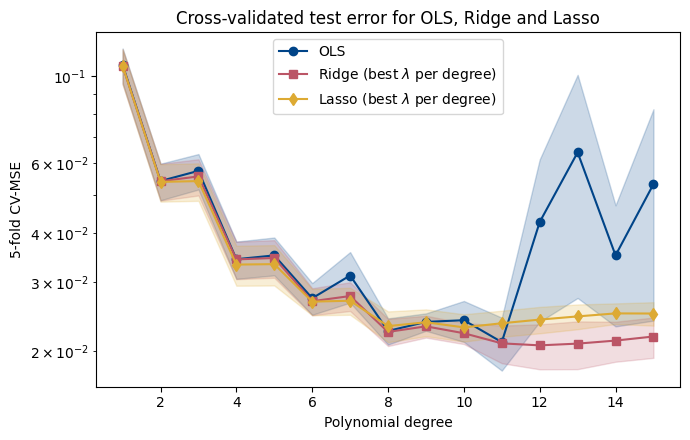

In [26]:

# From Part d): select the lowest CV-MSE over lambda for each polynomial degree
best_rid_per_degree = mse_rid_5k.min(axis=1)
best_lass_per_degree = mse_lass_5k.min(axis=1)

# Find the SE corresponding to the best lambda for each degree
rows = np.arange(len(degrees_boot))
best_se_rid = se_rid_5k[rows, mse_rid_5k.argmin(axis=1)]
best_se_lass = se_lass_5k[rows, mse_lass_5k.argmin(axis=1)]

# Compare the 5-fold CV-MSE of OLS, Ridge and Lasso as a function
# of polynomial degree, using the best lambda for Ridge and Lasso
plt.figure(figsize=(7, 4.5))

plt.plot(degrees_boot, mse_ols_5k, "o-", color=BLUE, label="OLS")
# ±1 SE band for OLS
plt.fill_between(degrees_boot, mse_ols_5k - se_ols_5k, mse_ols_5k + se_ols_5k,
                 color=BLUE, alpha=0.2) 

plt.plot(degrees_boot, best_rid_per_degree, "s-", color=RED, label=r"Ridge (best $\lambda$ per degree)")
# ±1 SE band for the best Ridge lambda at each degree
plt.fill_between(degrees_boot, best_rid_per_degree - best_se_rid, best_rid_per_degree + best_se_rid,
                 color=RED, alpha=0.2)  

plt.plot(degrees_boot, best_lass_per_degree, "d-", color=YELLOW, label=r"Lasso (best $\lambda$ per degree)")

# ±1 SE band for the best Lasso lambda at each degree
plt.fill_between(degrees_boot, best_lass_per_degree - best_se_lass, best_lass_per_degree + best_se_lass,
                 color=YELLOW, alpha=0.2)   

plt.yscale("log")
plt.xlabel("Polynomial degree")
plt.ylabel("5-fold CV-MSE")
plt.title("Cross-validated test error for OLS, Ridge and Lasso")
plt.legend()
plt.tight_layout()
plt.savefig('figures/i_CV_comparison.png')
plt.show()

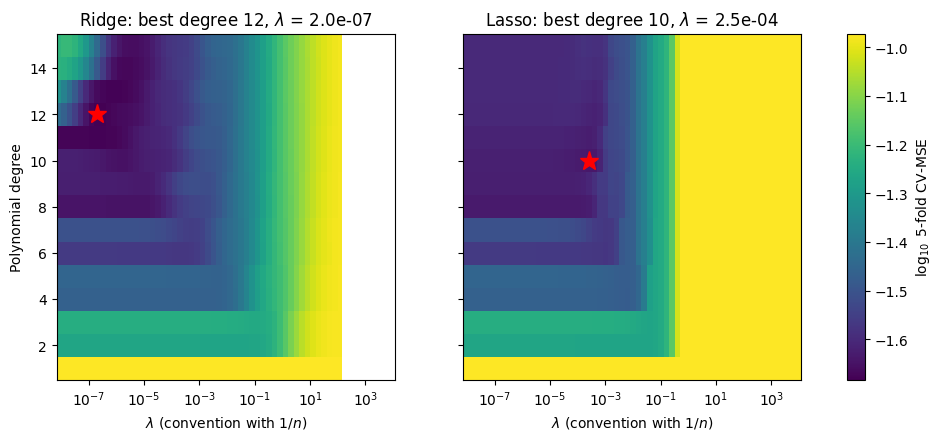

In [27]:
#Heatmap for Ridge and Lasso
""" Each rectangle is one model, y-axis: degree, x-axis: lambda, color = error """

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True, sharex=True)
vmin = np.log10(min(mse_rid_5k.min(), mse_lass_5k.min()))   # shared colour scale,
vmax = np.log10(max(mse_rid_5k.max(), mse_lass_5k.max()))   # so the two panels can be compared

for ax, M, name in zip(axes, (mse_rid_5k, mse_lass_5k), ("Ridge", "Lasso")):
    n_train = 80                                                  # training points per fold, 5-fold CV
    lam_axis = lambdas / n_train if name == "Ridge" else lambdas  # Ridge: convert to the 1/n convention to be able to compare with lasso
    im = ax.pcolormesh(lam_axis, degrees_boot, np.log10(M), shading="auto", vmin=vmin, vmax=vmax)
    i, j = np.unravel_index(np.argmin(M), M.shape)            # position of the minimum
    ax.plot(lam_axis[j], degrees_boot[i], "r*", ms=14)
    ax.set_xscale("log")
    ax.set_xlabel(r"$\lambda$ (convention with $1/n$)")
    ax.set_title(f"{name}: best degree {degrees_boot[i]}, $\\lambda$ = {lam_axis[j]:.1e}")
axes[0].set_ylabel("Polynomial degree")
fig.colorbar(im, ax=axes, label=r"$\log_{10}$ 5-fold CV-MSE")
plt.savefig('figures/i_heatmap.png')
plt.show()

In [28]:
#  best model and one-SE model for each method
def summarize(name, mse, se):
    """
    Summarize the minimum-CV-MSE model and the one-SE model.

    For OLS, mse and se are 1D arrays indexed by polynomial degree.
    For Ridge and Lasso, they are 2D arrays indexed by degree and lambda.
    """

    # OLS has no lambda parameter, so add a dummy lambda dimension to use the same procedure for all three methods.
    if mse.ndim == 1:                                   # OLS: no lambda
        best_lam = np.zeros(len(mse), dtype=int)
        mse, se = mse[:, None], se[:, None]
    else:
        # For each polynomial degree, find the lambda giving the lowest cross-validation MSE.
        best_lam = mse.argmin(axis=1)                   # best lambda index for each degree
    rows = np.arange(len(degrees_boot))
    # Select the best lambda and its corresponding MSE and SE for each polynomial degree.
    best_mse, best_se = mse[rows, best_lam], se[rows, best_lam]

    i = np.argmin(best_mse)                             # overall minimum

    # Apply the one-SE rule to select the simplest degree whose error is within one standard error of the minimum.
    d_1se, _ = one_se_rule(best_mse, best_se, degrees_boot)
    # Find the array index corresponding to the one-SE degree.
    r = np.where(degrees_boot == d_1se)[0][0]          

    # OLS has no lambda, while Ridge and Lasso report the lambda associated with the selected degree.
    lam_min = "-" if mse.shape[1] == 1 else f"{lambdas[best_lam[i]]:.1e}"
    lam_1se = "-" if mse.shape[1] == 1 else f"{lambdas[best_lam[r]]:.1e}"

    # Print the best model and the model selected by the one-SE rule.
    print(f"{name:<14} min: p={degrees_boot[i]:>2}, lambda={lam_min:>7}, MSE={best_mse[i]:.4f} ± {best_se[i]:.4f}"
          f"   one-SE: p={d_1se:>2}, lambda={lam_1se:>7}, MSE={best_mse[r]:.4f} ± {best_se[r]:.4f}")

# Apply the same summary procedure to OLS, Ridge and Lasso for both 5-fold and 10-fold cross-validation.
for k, (o, so, r_, sr, l, sl) in {5: (mse_ols_5k, se_ols_5k, mse_rid_5k, se_rid_5k, mse_lass_5k, se_lass_5k),
                                   10: (mse_ols_10k, se_ols_10k, mse_rid_10k, se_rid_10k, mse_lass_10k, se_lass_10k)}.items():
    summarize(f"OLS, k={k}", o, so)
    summarize(f"Ridge, k={k}", r_, sr)
    summarize(f"Lasso, k={k}", l, sl)

OLS, k=5       min: p=11, lambda=      -, MSE=0.0211 ± 0.0032   one-SE: p= 8, lambda=      -, MSE=0.0225 ± 0.0017
Ridge, k=5     min: p=12, lambda=1.6e-05, MSE=0.0207 ± 0.0027   one-SE: p= 8, lambda=4.0e-04, MSE=0.0224 ± 0.0018
Lasso, k=5     min: p=10, lambda=2.5e-04, MSE=0.0230 ± 0.0018   one-SE: p= 8, lambda=4.0e-05, MSE=0.0232 ± 0.0021
OLS, k=10      min: p=11, lambda=      -, MSE=0.0202 ± 0.0031   one-SE: p= 8, lambda=      -, MSE=0.0225 ± 0.0020
Ridge, k=10    min: p=12, lambda=1.0e-05, MSE=0.0192 ± 0.0026   one-SE: p=11, lambda=6.3e-05, MSE=0.0198 ± 0.0023
Lasso, k=10    min: p= 9, lambda=1.0e-08, MSE=0.0232 ± 0.0026   one-SE: p= 8, lambda=6.3e-05, MSE=0.0232 ± 0.0029


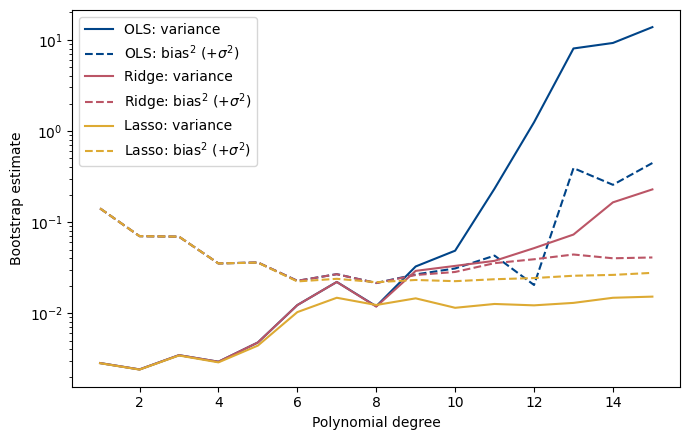

In [29]:
# Use the lambda values selected by cross-validation.
lam_ridge = 1.6e-5   # CV-best Ridge lambda (scikit-learn convention, no 1/n)
lam_lasso = 2.5e-4   # CV-best Lasso lambda (convention with 1/n), alpha = lambda/2

# Define the models used in the bias-variance analysis.
models = {
    "OLS":   (BLUE,   lambda d: make_pipeline(PolynomialFeatures(d, include_bias=False), StandardScaler(),
                                              LinearRegression())),
    "Ridge": (RED,    lambda d: make_pipeline(PolynomialFeatures(d, include_bias=False), StandardScaler(),
                                              Ridge(alpha=lam_ridge))),
    # Convert our lambda convention to scikit-learn's alpha convention.
    "Lasso": (YELLOW, lambda d: make_pipeline(PolynomialFeatures(d, include_bias=False), StandardScaler(),
                                              Lasso(alpha=lam_lasso / 2, max_iter=10000))),
}

fig, ax = plt.subplots(figsize=(7, 4.5))
# Estimate the bias and variance for each model over polynomial degree using bootstrap resampling.
for name, (color, make_model) in models.items():
    err, b2, var = bias_variance_sweep(n=100, make_model=make_model)
    # Plot the bootstrap estimate of the variance.
    ax.plot(degrees, var, "-", color=color, label=f"{name}: variance")
     # Plot the squared bias including the irreducible noise variance.
    ax.plot(degrees, b2, "--", color=color, label=rf"{name}: bias$^2$ (+$\sigma^2$)")
# Use a logarithmic scale to make differences across degrees easier to see.
ax.set_yscale("log")
ax.set_xlabel("Polynomial degree")
ax.set_ylabel("Bootstrap estimate")
ax.legend()

plt.savefig('figures/i_boot_errors.png')
plt.tight_layout()
plt.show()

## Background literature

- The lecture notes of the course, in particular Chapter 2 (Sections 2.9–2.12
  on training and test error, the bias-variance tradeoff, the bootstrap and
  cross-validation), Chapter 3 (linear regression, Ridge, Lasso, scaling) and
  Chapter 4 (gradient descent methods and automatic differentiation).
- For a discussion and derivation of the variances and mean squared errors
  using linear regression, see the
  [Lecture notes on ridge regression by Wessel N. van Wieringen](https://arxiv.org/abs/1509.09169).
- The textbook of
  [Trevor Hastie, Robert Tibshirani, Jerome H. Friedman, The Elements of Statistical Learning, Springer](https://www.springer.com/gp/book/9780387848570);
  chapters 3 and 7 are the most relevant ones for the analysis here.
- On automatic differentiation:
  [Baydin et al., Automatic differentiation in machine learning: a survey, JMLR 18 (2018)](https://jmlr.org/papers/v18/17-468.html),
  and the [JAX documentation](https://jax.readthedocs.io).

## Introduction to numerical projects

Here follows a brief recipe and recommendation on how to answer the various
questions when preparing your answers.

- Give a short description of the nature of the problem and the eventual
  numerical methods you have used.
- Describe the algorithm you have used and/or developed. Here you may find it
  convenient to use pseudocoding. In many cases you can describe the algorithm
  in the program itself.
- Include the source code of your program. Comment your program properly. You
  should have the code at your GitHub/GitLab link. You can also place the code
  in an appendix of your report.
- If possible, try to find analytic solutions, or known limits in order to test
  your program when developing the code. In this project the closed-form OLS
  and Ridge solutions are exactly such tests for your gradient descent codes.
- Include your results either in figure form or in a table. Remember to label
  your results. All tables and figures should have relevant captions and labels
  on the axes.
- Try to evaluate the reliability and numerical stability/precision of your
  results. If possible, include a qualitative and/or quantitative discussion of
  the numerical stability, eventual loss of precision etc.
- Try to give an interpretation of your results in your answers to the
  problems.
- Critique: if possible include your comments and reflections about the
  exercise, whether you felt you learnt something, ideas for improvements and
  other thoughts you've made when solving the exercise. We wish to keep this
  course at the interactive level and your comments can help us improve it.
- Try to establish a practice where you log your work at the computer lab. You
  may find such a logbook very handy at later stages in your work, especially
  when you don't properly remember what a previous test version of your program
  did. Here you could also record the time spent on solving the exercise,
  various algorithms you may have tested or other topics which you feel worthy
  of mentioning.

## Format for electronic delivery of report and programs

The preferred format for the report is a PDF file. You can also use DOC or
postscript formats or an IPython notebook file. As programming language we
prefer that you choose between C/C++, Fortran2008, Julia or Python. The
following prescription should be followed when preparing the report:

- Use Canvas to hand in your projects, log in at
  <https://www.uio.no/english/services/it/education/canvas/> with your normal
  UiO username and password.
- Upload **only** the report file or the link to your GitHub/GitLab or similar
  type of repository! For the source code file(s) you have developed please
  provide us with your link to your GitHub/GitLab or similar domain. The report
  file should include all of your discussions and a list of the codes you have
  developed. Do not include library files which are available at the course
  homepage, unless you have made specific changes to them.
- In your GitHub/GitLab or similar repository, please include a folder which
  contains selected results. These can be in the form of output from your code
  for a selected set of runs and input parameters.

Finally, we encourage you to collaborate. Optimal working groups consist of 2–3
students. You can then hand in a common report.

## Software and needed installations

If you have Python installed (we recommend Python 3) and you feel pretty
familiar with installing different packages, we recommend that you install the
following Python packages via `pip` as

    pip install numpy scipy matplotlib ipython jupyter scikit-learn pandas jax jaxlib

(`autograd` is a lighter alternative to JAX for the automatic differentiation in
parts e)–g)). For Python 3, replace `pip` with `pip3` where needed.

For OSX users we recommend also, after having installed Xcode, to install
`brew`. Brew allows for a seamless installation of additional software via for
example `brew install python3`. For Linux users, with its variety of
distributions like for example the widely popular Ubuntu distribution, you can
use `pip` as well and simply install Python as `sudo apt-get install python3`
etc.

If you don't want to install various Python packages with their dependencies
separately, we recommend [Anaconda](https://docs.anaconda.com/), an open source
distribution of the Python and R programming languages for large-scale data
processing, predictive analytics, and scientific computing, that aims to
simplify package management and deployment. Package versions are managed by the
package management system `conda`.

Popular software packages written in Python for ML are
[Scikit-learn](http://scikit-learn.org/stable/), [JAX](https://jax.readthedocs.io),
[TensorFlow](https://www.tensorflow.org/), [PyTorch](http://pytorch.org/) and
[Keras](https://keras.io/). These are all freely available at their respective
GitHub sites. They encompass communities of developers in the thousands or more,
and the number of code developers and contributors keeps increasing.